# Pipeline final DeepLabV3-ResNet50: entrenar o exportar GeoJSON para QuPath

Este notebook está pensado para usar el mejor modelo seleccionado en los experimentos: **DeepLabV3 con encoder ResNet50 preentrenado en ImageNet**.

Permite dos modos:

1. **`RUN_MODE = "train"`**: reentrenar o continuar entrenamiento añadiendo nuevas imágenes al conjunto de entrenamiento.
2. **`RUN_MODE = "export"`**: cargar un checkpoint, evaluar un caso y exportar la predicción a **GeoJSON compatible con QuPath** usando `bbox_global` para conservar las coordenadas correctas.
3.  **`RUN_MODE = "predict_full"`**: cargar un checkpoint, evaluar un caso en imagen completa nueva y exportar la predicción a **GeoJSON compatible con QuPath**.

In [1]:
import json
import os
import math
import random
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
from pathlib import Path
import matplotlib.pyplot as plt
import re
import gc
from tqdm import tqdm

import rasterio
from rasterio.windows import Window
from scipy import ndimage

import albumentations as A
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

import cv2

from IPython.display import display


In [2]:

# =============================================================================
# CONFIGURACIÓN PRINCIPAL
# =============================================================================
# Cambia SOLO esta variable según lo que quieras hacer:
#   "train"  -> reentrenar DeepLabV3-ResNet50, usando todas las imágenes/geojsons disponibles.
#   "export" -> cargar un checkpoint ya entrenado, evaluar un caso anotado y exportar GeoJSON para QuPath.
#   "predict_full" -> cargar un checkpoint ya entrenado y evaluar una imagen completa nueva
RUN_MODE = "predict_full"   # "train", "export" o "predict_full"

# Carpetas de entrada.
# Para añadir más imágenes al entrenamiento:
#   1) copia las nuevas imágenes .ome.tiff/.tif en TFM/imagenes
#   2) copia sus anotaciones .geojson en TFM/geojsons
#   3) pon RUN_MODE = "train"
BASE_PATH = Path("TFM")
IMAGES_DIR = BASE_PATH / "imagenes"
GEOJSON_DIR = BASE_PATH / "geojsons"

# Carpeta de resultados.
OUTPUT_DIR = Path("resultados_deeplab_final")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
GEOJSON_OUTPUT_DIR = OUTPUT_DIR / "geojson_qupath"
PLOTS_DIR = OUTPUT_DIR / "figuras"
TABLES_DIR = OUTPUT_DIR / "tablas"

for d in [OUTPUT_DIR, CHECKPOINT_DIR, GEOJSON_OUTPUT_DIR, PLOTS_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Clases
CLASS_ORDER = ["BACKGROUND", "no tumor", "Tumor"]
CLASS_TO_ID = {
    "BACKGROUND": 0,
    "no tumor": 1,
    "Tumor": 2
}
ID_TO_CLASS = {v: k for k, v in CLASS_TO_ID.items()}

NUM_CLASSES = len(CLASS_TO_ID)
TUMOR_ID = CLASS_TO_ID["Tumor"]
NOTUMOR_ID = CLASS_TO_ID["no tumor"]

ID_TO_COLOR = {
    0: [0, 0, 255],      # background -> azul
    1: [255, 255, 0],    # no tumor -> amarillo
    2: [0, 255, 0],      # tumor -> verde
    255: [0, 0, 0],      # ignore -> negro
}

ID_TO_NAME = {
    0: "BACKGROUND",
    1: "no tumor",
    2: "Tumor"
}

IGNORE_INDEX = 255

# Mejor configuración seleccionada previamente
MODEL_ARCHITECTURE = "deeplabv3"
ENCODER_NAME = "resnet50"
ENCODER_WEIGHTS = "imagenet"

PATCH_SIZE = 256
STRIDE = 128
MIN_VALID_RATIO = 0.80
MERGE_CLOSE_ROIS_PX = 0

LOSS_NAME = "ce_dice"
BATCH_SIZE = 4
NUM_EPOCHS = 10
LR = 1e-3
WEIGHT_DECAY = 0.0
PATIENCE = 5
MIN_DELTA = 0.001
SEED = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =============================================================================
# CONFIGURACIÓN PARA ENTRENAR / AÑADIR MÁS IMÁGENES
# =============================================================================
# split_mode:
#   "fixed_plus_new_train" -> conserva val/test originales y mete casos nuevos en train.
#   "fixed"                -> usa solo el split fijo original.
#   "auto_balanced"        -> recalcula el split con todos los casos disponibles.
SPLIT_MODE = "fixed_plus_new_train"

FIXED_TRAIN_CASE_IDS = [
    "B2275S15", "B2344S18_1", "B23129S13_1", "B23129S13_2", "B2356S13",
    "B2299CR2", "B2290CR1", "B241S21", "B2292CR2", "B2249CR2"
]
FIXED_VAL_CASE_IDS = ["B2277CR3_1", "B2279CR1"]
FIXED_TEST_CASE_IDS = ["B2291CR1_1", "B2291CR1_3", "B21122CR6"]

# Si quieres continuar desde un checkpoint anterior, pon TRAIN_FROM_CHECKPOINT = True.
# Si quieres reentrenar desde ImageNet, ponlo en False.
TRAIN_FROM_CHECKPOINT = False
CHECKPOINT_TO_CONTINUE = CHECKPOINT_DIR / "modelo_final_final_best.pth"

# Nombre del checkpoint que se guardará al entrenar.
TRAIN_OUTPUT_CHECKPOINT = CHECKPOINT_DIR / "modelo_final_deeplab_reentrenado_best.pth"

# =============================================================================
# CONFIGURACIÓN PARA EXPORTAR GEOJSON A QUPATH
# =============================================================================
# Ruta al checkpoint que quieres cargar para inferencia/exportación.
# Cambia esta ruta por tu .pth real.
BEST_MODEL_PATH = Path("resultados_tfm_model_selection") / "checkpoints" / "modelo_final_seleccionado_best.pt"

# Caso que quieres exportar. Si lo dejas en None, se usará el primer caso disponible.
CASE_ID_TO_EXPORT =  "B2291CR1_1" # ejemplo: "B21122CR6"

# Por defecto exportamos solo tumor. Si quieres exportar no tumor también: EXPORT_CLASSES = (1, 2)
EXPORT_CLASSES = (1, 2)

EXPORT_MIN_AREA = 1000
EXPORT_SIMPLIFY_EPSILON = 3.0
EXPORT_MORPH_KERNEL_SIZE = 5
EXPORT_BATCH_SIZE = 1

SHOW_VISUAL_CHECK_BEFORE_EXPORT = True
EXPORT_DEBUG_BBOX = True

# Validaciones visuales durante preprocesado
VALIDATE_CASES = "none"       # "none", "first", "all" o lista de case_id
SHOW_ROIS = True
SHOW_PATCHES_PER_VALIDATED_CASE = True
N_PATCHES_PER_VALIDATED_CASE = 6
SHOW_GLOBAL_PATCH_VALIDATION = False
N_GLOBAL_PATCHES = 8



# =============================================================================
# CONFIGURACIÓN PARA PREDECIR UNA IMAGEN COMPLETA SIN ANOTACIÓN
# =============================================================================

# Imagen nueva, sin GeoJSON.
FULL_IMAGE_PATH = IMAGES_DIR / "B2291CR1_1.ome.tif"

# Nombre que se usará para guardar las salidas.
FULL_CASE_ID = FULL_IMAGE_PATH.stem

# Clases a exportar.
# Solo tumor:
# FULL_EXPORT_CLASSES = (2,)
# Tumor y no tumor:
FULL_EXPORT_CLASSES = (1, 2)

# Parámetros de inferencia sobre imagen completa.
FULL_PATCH_SIZE = 256
FULL_STRIDE = 128
FULL_BATCH_SIZE = 1

# Parámetros GeoJSON.
FULL_EXPORT_MIN_AREA = 1000
FULL_EXPORT_SIMPLIFY_EPSILON = 3.0
FULL_EXPORT_MORPH_KERNEL_SIZE = 5

SHOW_FULL_VISUAL_CHECK = True


DEVICE: cuda


In [3]:

# =============================================================================
# REPRODUCIBILIDAD
# =============================================================================
def set_reproducibility(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    # Evita pequeñas diferencias por TF32 en Ampere o superior.
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

    # warn_only=True evita que el notebook se pare si alguna operación CUDA no tiene alternativa determinista.
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception as e:
        print("Aviso: no se pudo activar determinismo completo:", e)

set_reproducibility(SEED)


In [4]:

def remove_known_suffixes(filename):
    """
    Quita sufijos típicos:
    .ome.tif, .ome.tiff, .tif, .tiff, .geojson
    """
    name = filename.lower()

    for suf in [".ome.tiff", ".ome.tif", ".tiff", ".tif", ".geojson"]:
        if name.endswith(suf):
            return filename[: -len(suf)]

    return Path(filename).stem


def collect_files(folder, extensions):
    folder = Path(folder)
    files = []

    for p in folder.rglob("*"):
        if p.is_file():
            low = p.name.lower()
            if any(low.endswith(ext) for ext in extensions):
                files.append(p)

    return sorted(files)


def match_images_and_geojsons(images_dir, geojson_dir):
    image_files = collect_files(images_dir, [".ome.tif", ".ome.tiff", ".tif", ".tiff"])
    geojson_files = collect_files(geojson_dir, [".geojson"])

    image_map = {remove_known_suffixes(p.name): p for p in image_files}
    geojson_map = {remove_known_suffixes(p.name): p for p in geojson_files}

    common_keys = sorted(set(image_map.keys()) & set(geojson_map.keys()))
    only_images = sorted(set(image_map.keys()) - set(geojson_map.keys()))
    only_geojsons = sorted(set(geojson_map.keys()) - set(image_map.keys()))

    pairs = []
    for key in common_keys:
        pairs.append({
            "case_id": key,
            "image_path": image_map[key],
            "geojson_path": geojson_map[key]
        })

    print(f"Casos emparejados: {len(pairs)}")

    if only_images:
        print("\nImágenes sin geojson:")
        for x in only_images:
            print(" ", x)

    if only_geojsons:
        print("\nGeojsons sin imagen:")
        for x in only_geojsons:
            print(" ", x)

    return pairs



In [5]:
def load_geojson_features(path):
    """
    leer geojson, extraer geometría MultiPolygon
    """
    with open(path, "r", encoding="utf-8") as f:
        geo = json.load(f)
    return geo["features"]

def update_bbox_from_coords(coords, bbox):
    """
    bbox = [minx, miny, maxx, maxy]
    """
    if isinstance(coords[0], (int, float)):
        x, y = coords[:2]
        bbox[0] = min(bbox[0], x)
        bbox[1] = min(bbox[1], y)
        bbox[2] = max(bbox[2], x)
        bbox[3] = max(bbox[3], y)
    else:
        for c in coords:
            update_bbox_from_coords(c, bbox)

def get_global_bbox(features, pad=0):
    """
    en vez de leer toda la imagen leo solo la zona donde hay anotaciones
    """
    bbox = [float("inf"), float("inf"), -float("inf"), -float("inf")]
    for feat in features:
        update_bbox_from_coords(feat["geometry"]["coordinates"], bbox)

    minx, miny, maxx, maxy = bbox
    x0 = math.floor(minx) - pad
    y0 = math.floor(miny) - pad
    x1 = math.ceil(maxx) + pad + 1
    y1 = math.ceil(maxy) + pad + 1

    return x0, y0, x1, y1

def read_rgb_window(img_path, x0, y0, x1, y1):
    """
    leer ROI global del TIFF
    """
    w = x1 - x0
    h = y1 - y0

    with rasterio.open(img_path) as src:
        window = Window(x0, y0, w, h)
        arr = src.read([1, 2, 3], window=window)    # (3, H, W)
        arr = np.moveaxis(arr, 0, -1)               # (H, W, 3)

    return arr

import rasterio
import numpy as np
from pathlib import Path


def read_full_rgb_image(img_path):
    """
    Lee la imagen completa usando read_rgb_window.
    Devuelve un array RGB con forma (H, W, 3).
    """
    img_path = Path(img_path)

    if not img_path.exists():
        raise FileNotFoundError(f"No existe la imagen: {img_path}")

    with rasterio.open(img_path) as src:
        width = src.width
        height = src.height

    print("Leyendo imagen completa:")
    print("Width:", width)
    print("Height:", height)

    image = read_rgb_window(
        img_path=img_path,
        x0=0,
        y0=0,
        x1=width,
        y1=height
    )

    image = np.asarray(image)

    if image.dtype != np.uint8:
        image = image.astype(np.float32)
        image = image - image.min()

        if image.max() > 0:
            image = image / image.max()

        image = (image * 255).astype(np.uint8)

    return image

In [6]:
def shift_ring_to_local(ring, x_offset, y_offset):
    """
    mover coordenadas globales a locales
    """
    pts = []
    for pt in ring:
        x, y = pt[:2]
        pts.append((int(round(x - x_offset)), int(round(y - y_offset))))
    return pts

def rasterize_polygon_with_holes(polygon_coords, width, height, x_offset, y_offset):
    """
    dibujar el polígono, crea imagen vacía en negro y luego dibuja el polígono exterior en blanco
    polygon_coords = [outer_ring, hole1, hole2, ...]
    """
    mask_img = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(mask_img)

    outer = shift_ring_to_local(polygon_coords[0], x_offset, y_offset)
    draw.polygon(outer, fill=1)

    for hole in polygon_coords[1:]:
        hole_pts = shift_ring_to_local(hole, x_offset, y_offset)
        draw.polygon(hole_pts, fill=0)

    return np.array(mask_img, dtype=bool)

def feature_to_mask(feature, width, height, x_offset, y_offset):
    geom = feature["geometry"]
    geom_type = geom["type"]
    coords = geom["coordinates"]

    mask = np.zeros((height, width), dtype=bool)

    if geom_type == "Polygon":
        mask |= rasterize_polygon_with_holes(coords, width, height, x_offset, y_offset)

    elif geom_type == "MultiPolygon":
        for polygon in coords:
            mask |= rasterize_polygon_with_holes(polygon, width, height, x_offset, y_offset)

    else:
        raise ValueError(f"Geometría no soportada: {geom_type}")

    return mask

def build_class_masks(features, x0, y0, x1, y1):
    """
    unir todas anotaciones de cada clase
    """
    w = x1 - x0
    h = y1 - y0

    masks = {cls: np.zeros((h, w), dtype=bool) for cls in CLASS_ORDER}

    for feat in features:
        cls = feat["properties"]["classification"]["name"]
        if cls not in CLASS_TO_ID:
            continue
        feat_mask = feature_to_mask(feat, w, h, x0, y0)
        masks[cls] |= feat_mask

    return masks
"""
def build_semantic_mask(class_masks):
"""
    #Empieza en IGNORE_INDEX y luego pinta clases con prioridad:
    #BACKGROUND < no tumor < Tumor

    #crear máscara final multiclase
"""
    h, w = next(iter(class_masks.values())).shape
    semantic_mask = np.full((h, w), IGNORE_INDEX, dtype=np.uint8)

    for cls in CLASS_ORDER:
        semantic_mask[class_masks[cls]] = CLASS_TO_ID[cls]

    return semantic_mask
  """

def build_semantic_mask(masks, ignore_index=255):
    h, w = next(iter(masks.values())).shape
    semantic_mask = np.full((h, w), ignore_index, dtype=np.uint8)

    background = masks["BACKGROUND"]
    no_tumor = masks["no tumor"] & (~background)
    tumor = masks["Tumor"] & (~background)

    semantic_mask[no_tumor] = 1
    semantic_mask[tumor] = 2
    semantic_mask[background] = 0

    return semantic_mask

In [7]:
def find_connected_rois(semantic_mask, merge_close_rois_px=0):
    """
    Devuelve cajas (x0, y0, x1, y1) en coordenadas LOCALES al crop global.
    """
    valid = semantic_mask != IGNORE_INDEX

    if merge_close_rois_px > 0:
        valid = ndimage.binary_dilation(valid, iterations=merge_close_rois_px)

    labeled, n = ndimage.label(valid)

    roi_boxes = []
    objects = ndimage.find_objects(labeled)

    for sl in objects:
        if sl is None:
            continue
        y_slice, x_slice = sl
        y0, y1 = y_slice.start, y_slice.stop
        x0, x1 = x_slice.start, x_slice.stop
        roi_boxes.append((x0, y0, x1, y1))

    return roi_boxes

In [8]:
def crop_rois(image_global, mask_global, roi_boxes):
    rois = []

    for i, (x0, y0, x1, y1) in enumerate(roi_boxes):
        img_roi = image_global[y0:y1, x0:x1]
        mask_roi = mask_global[y0:y1, x0:x1]

        rois.append({
            "roi_id": i,
            "bbox_local": (x0, y0, x1, y1),
            "image": img_roi,
            "mask": mask_roi
        })

    return rois

In [9]:
def mask_to_color(mask, id_to_color=ID_TO_COLOR):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)

    for label, color in id_to_color.items():
        color_mask[mask == label] = color

    return color_mask
def make_overlay(image, mask, alpha=0.35, ignore_index=255):
    """
    image: H x W x 3
    mask:  H x W
    """
    color_mask = mask_to_color(mask)
    overlay = image.copy()

    valid = mask != ignore_index
    overlay[valid] = (
        (1 - alpha) * image[valid] + alpha * color_mask[valid]
    ).astype(np.uint8)

    return overlay

def validate_global_mask(image, mask, title="Máscara global", ignore_index=255):
    print("Shape imagen:", image.shape)
    print("Shape máscara:", mask.shape)

    unique, counts = np.unique(mask, return_counts=True)
    print("\nValores únicos y conteos:")
    for u, c in zip(unique, counts):
        print(f"  clase {u}: {c} píxeles")

    overlay = make_overlay(image, mask, ignore_index=ignore_index)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Imagen")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_to_color(mask))
    plt.title("Máscara coloreada")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def validate_rois(rois, ignore_index=255):
    print("Número de ROIs:", len(rois))

    for roi in rois:
        img = roi["image"]
        mask = roi["mask"]
        roi_id = roi["roi_id"]
        bbox = roi["bbox_local"]

        print(f"\nROI {roi_id}")
        print("  bbox_local:", bbox)
        print("  image shape:", img.shape)
        print("  mask shape:", mask.shape)

        unique, counts = np.unique(mask, return_counts=True)
        print("  clases:")
        for u, c in zip(unique, counts):
            print(f"    {u}: {c}")

        overlay = make_overlay(img, mask, ignore_index=ignore_index)

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(img)
        plt.title(f"ROI {roi_id} - imagen")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(mask_to_color(mask))
        plt.title(f"ROI {roi_id} - máscara")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(overlay)
        plt.title(f"ROI {roi_id} - overlay")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

In [10]:
def sliding_positions(length, patch_size, stride):
    if length <= patch_size:
        return [0]

    positions = list(range(0, length - patch_size + 1, stride))
    if positions[-1] != length - patch_size:
        positions.append(length - patch_size)

    return positions

def pad_to_min_size(image, mask, min_h, min_w, ignore_index=255):
    h, w = mask.shape

    pad_h = max(0, min_h - h)
    pad_w = max(0, min_w - w)

    if pad_h == 0 and pad_w == 0:
        return image, mask

    # imagen: reflect
    image = np.pad(
        image,
        ((0, pad_h), (0, pad_w), (0, 0)),
        mode="reflect"
    )

    # máscara: ignore
    mask = np.pad(
        mask,
        ((0, pad_h), (0, pad_w)),
        mode="constant",
        constant_values=ignore_index
    )

    return image, mask

def extract_patches_from_roi(image, mask, patch_size=256, stride=128,
                             ignore_index=255, min_valid_ratio=0.8):
    image, mask = pad_to_min_size(image, mask, patch_size, patch_size, ignore_index)

    h, w = mask.shape
    ys = sliding_positions(h, patch_size, stride)
    xs = sliding_positions(w, patch_size, stride)

    patches = []

    for y in ys:
        for x in xs:
            img_patch = image[y:y+patch_size, x:x+patch_size]
            mask_patch = mask[y:y+patch_size, x:x+patch_size]

            valid_ratio = np.mean(mask_patch != ignore_index)

            if valid_ratio >= min_valid_ratio:
                patches.append((img_patch, mask_patch))

    return patches

In [11]:
def dataset_report(
    patches,
    class_names=None,
    ignore_index=255,
    dominance_threshold=0.5,
    verbose=True
):
    """
    patches: lista de tuplas (img_patch, mask_patch)
    class_names: dict, por ejemplo {0:"BACKGROUND", 1:"no tumor", 2:"Tumor"}
    ignore_index: valor usado para píxeles no anotados
    dominance_threshold: un patch se considera "dominado" por una clase
                         si esa clase ocupa al menos este porcentaje
                         de los píxeles válidos del patch
    """

    if len(patches) == 0:
        print("No hay patches.")
        return None

    # -------------------------
    # acumuladores globales
    # -------------------------
    pixel_counts = {}
    present_in_patch = {}
    dominant_patch_counts = {}
    valid_ratios = []

    total_patches = len(patches)
    total_valid_pixels = 0
    total_ignore_pixels = 0

    for patch in patches:
        _, mask = unpack_patch(patch)
        vals, counts = np.unique(mask, return_counts=True)

        # pasar a dict simple
        count_dict = {int(v): int(c) for v, c in zip(vals, counts)}

        ignore_pixels = count_dict.get(ignore_index, 0)
        valid_pixels = mask.size - ignore_pixels

        total_valid_pixels += valid_pixels
        total_ignore_pixels += ignore_pixels
        valid_ratios.append(valid_pixels / mask.size)

        # conteos globales por clase
        for cls_id, c in count_dict.items():
            if cls_id == ignore_index:
                continue
            pixel_counts[cls_id] = pixel_counts.get(cls_id, 0) + c

        # clases presentes en este patch
        present_classes = [cls_id for cls_id in count_dict if cls_id != ignore_index]
        for cls_id in present_classes:
            present_in_patch[cls_id] = present_in_patch.get(cls_id, 0) + 1

        # clase dominante del patch
        if valid_pixels > 0:
            valid_class_counts = {
                cls_id: c for cls_id, c in count_dict.items()
                if cls_id != ignore_index
            }

            dominant_cls = max(valid_class_counts, key=valid_class_counts.get)
            dominant_ratio = valid_class_counts[dominant_cls] / valid_pixels

            if dominant_ratio >= dominance_threshold:
                dominant_patch_counts[dominant_cls] = (
                    dominant_patch_counts.get(dominant_cls, 0) + 1
                )

    # -------------------------
    # helper nombre clase
    # -------------------------
    def cls_name(cls_id):
        if class_names is None:
            return str(cls_id)
        return class_names.get(cls_id, str(cls_id))

    # -------------------------
    # preparar resultados
    # -------------------------
    pixel_percentages = {}
    for cls_id, c in pixel_counts.items():
        pixel_percentages[cls_id] = 100 * c / total_valid_pixels if total_valid_pixels > 0 else 0.0

    patch_presence_percentages = {}
    for cls_id, c in present_in_patch.items():
        patch_presence_percentages[cls_id] = 100 * c / total_patches

    dominant_patch_percentages = {}
    for cls_id, c in dominant_patch_counts.items():
        dominant_patch_percentages[cls_id] = 100 * c / total_patches

    report = {
        "total_patches": total_patches,
        "total_valid_pixels": total_valid_pixels,
        "total_ignore_pixels": total_ignore_pixels,
        "mean_valid_ratio": float(np.mean(valid_ratios)),
        "min_valid_ratio": float(np.min(valid_ratios)),
        "max_valid_ratio": float(np.max(valid_ratios)),
        "pixel_counts": pixel_counts,
        "pixel_percentages": pixel_percentages,
        "present_in_patch": present_in_patch,
        "patch_presence_percentages": patch_presence_percentages,
        "dominant_patch_counts": dominant_patch_counts,
        "dominant_patch_percentages": dominant_patch_percentages,
        "dominance_threshold": dominance_threshold,
    }

    # -------------------------
    # imprimir bonito
    # -------------------------
    if verbose:
        print("=" * 60)
        print("INFORME DEL DATASET DE PATCHES")
        print("=" * 60)

        print(f"\nTotal patches: {total_patches}")
        print(f"Total píxeles válidos: {total_valid_pixels:,}")
        print(f"Total píxeles ignore: {total_ignore_pixels:,}")
        print(f"Valid ratio medio: {np.mean(valid_ratios):.4f}")
        print(f"Valid ratio mínimo: {np.min(valid_ratios):.4f}")
        print(f"Valid ratio máximo: {np.max(valid_ratios):.4f}")

        print("\n--- Conteos globales por clase ---")
        for cls_id in sorted(pixel_counts):
            print(f"{cls_name(cls_id):>12}: {pixel_counts[cls_id]:>12,} píxeles")

        print("\n--- Porcentajes globales por clase ---")
        for cls_id in sorted(pixel_percentages):
            print(f"{cls_name(cls_id):>12}: {pixel_percentages[cls_id]:>11.2f}%")

        print("\n--- Patches en los que aparece cada clase ---")
        for cls_id in sorted(present_in_patch):
            c = present_in_patch[cls_id]
            pct = patch_presence_percentages[cls_id]
            print(f"{cls_name(cls_id):>12}: {c:>12} patches ({pct:>6.2f}%)")

        print(f"\n--- Patches dominados por clase (umbral {dominance_threshold:.2f}) ---")
        all_cls_ids = sorted(pixel_counts.keys())
        for cls_id in all_cls_ids:
            c = dominant_patch_counts.get(cls_id, 0)
            pct = dominant_patch_percentages.get(cls_id, 0.0)
            print(f"{cls_name(cls_id):>12}: {c:>12} patches ({pct:>6.2f}%)")

        print("=" * 60)

    return report

In [12]:
def unpack_patch(patch):
    if isinstance(patch, dict):
        return patch["image"], patch["mask"]
    return patch

def show_random_patches(patches, n=6, title_prefix=""):
    if len(patches) == 0:
        print("No hay patches para mostrar.")
        return

    idxs = random.sample(range(len(patches)), min(n, len(patches)))

    plt.figure(figsize=(12, 4 * len(idxs)))
    row = 1

    for idx in idxs:
        img_patch, mask_patch = unpack_patch(patches[idx])

        plt.subplot(len(idxs), 3, row)
        plt.imshow(img_patch)
        plt.title(f"{title_prefix}Patch {idx} - imagen")
        plt.axis("off")

        plt.subplot(len(idxs), 3, row + 1)
        plt.imshow(mask_to_color(mask_patch))
        plt.title("máscara")
        plt.axis("off")

        plt.subplot(len(idxs), 3, row + 2)
        plt.imshow(make_overlay(img_patch, mask_patch, alpha=0.25, ignore_index=255))
        plt.title("overlay")
        plt.axis("off")

        row += 3

    plt.tight_layout()
    plt.show()

def patch_stats(patches, ignore_index=255):
    if len(patches) == 0:
        print("No hay patches.")
        return

    valid_ratios = []
    class_hist = {}

    for patch in patches:
        _, mask = unpack_patch(patch)
        valid_ratios.append(np.mean(mask != ignore_index))

        vals, counts = np.unique(mask, return_counts=True)
        for v, c in zip(vals, counts):
            class_hist[v] = class_hist.get(v, 0) + c

    print("Número de patches:", len(patches))
    print("Valid ratio medio:", np.mean(valid_ratios))
    print("Valid ratio min:", np.min(valid_ratios))
    print("Valid ratio max:", np.max(valid_ratios))
    print("Histograma global de clases:", class_hist)

def class_percentages_from_patches(patches, class_names=None, ignore_index=255):
    total_counts = {}

    for patch in patches:
        _, mask = unpack_patch(patch)
        vals, counts = np.unique(mask, return_counts=True)
        for v, c in zip(vals, counts):
            if v == ignore_index:
                continue
            total_counts[int(v)] = total_counts.get(int(v), 0) + int(c)

    total = sum(total_counts.values())

    print("Conteos globales:")
    for cls_id in sorted(total_counts):
        name = class_names.get(cls_id, str(cls_id)) if class_names else str(cls_id)
        pct = 100 * total_counts[cls_id] / total
        print(f"  {name}: {total_counts[cls_id]:,} píxeles ({pct:.2f}%)")

def patches_per_class(patches, class_names=None, ignore_index=255):
    patch_count = len(patches)
    contains = {}

    for patch in patches:
        _, mask = unpack_patch(patch)
        present = set(np.unique(mask))
        if ignore_index in present:
            present.remove(ignore_index)

        for cls in present:
            cls = int(cls)
            contains[cls] = contains.get(cls, 0) + 1

    print(f"Total patches: {patch_count}")
    for cls_id in sorted(contains):
        name = class_names.get(cls_id, str(cls_id)) if class_names else str(cls_id)
        pct = 100 * contains[cls_id] / patch_count
        print(f"  {name}: aparece en {contains[cls_id]} patches ({pct:.2f}%)")

def per_patch_class_distribution(patches, class_names=None, ignore_index=255, n=10):
    if len(patches) == 0:
        print("No hay patches.")
        return

    idxs = random.sample(range(len(patches)), min(n, len(patches)))

    for idx in idxs:
        _, mask = unpack_patch(patches[idx])
        vals, counts = np.unique(mask, return_counts=True)

        valid_total = counts[vals != ignore_index].sum()

        print(f"\nPatch {idx}")
        for v, c in zip(vals, counts):
            if v == ignore_index:
                continue
            name = class_names.get(int(v), str(v)) if class_names else str(v)
            pct = 100 * c / valid_total
            print(f"  {name}: {pct:.2f}%")

def tumor_vs_nontumor_ratio(patches, tumor_id=2, nontumor_id=1, ignore_index=255):
    tumor_pixels = 0
    nontumor_pixels = 0

    for patch in patches:
        _, mask = unpack_patch(patch)
        tumor_pixels += np.sum(mask == tumor_id)
        nontumor_pixels += np.sum(mask == nontumor_id)

    print("Tumor píxeles:", tumor_pixels)
    print("No tumor píxeles:", nontumor_pixels)

    if nontumor_pixels > 0:
        print("Ratio tumor/no_tumor:", tumor_pixels / nontumor_pixels)


In [13]:
def should_validate_case(case_id, case_index, total_cases, mode):
    if mode is None or mode == "none":
        return False
    if mode == "all":
        return True
    if mode == "first":
        return case_index == 0
    if isinstance(mode, (list, tuple, set)):
        return case_id in mode
    return False


def validate_case_intermediate_outputs(case_result):
    case_id = case_result["case_id"]

    print("\n" + "-" * 80)
    print(f"VALIDACIÓN INTERMEDIA DEL CASO: {case_id}")
    print("-" * 80)

    validate_global_mask(
        case_result["image_global"],
        case_result["semantic_mask"],
        title=f"Caso {case_id} - máscara global",
        ignore_index=IGNORE_INDEX
    )

    if SHOW_ROIS:
        validate_rois(case_result["rois"], ignore_index=IGNORE_INDEX)

    case_patch_tuples = [(p["image"], p["mask"]) for p in case_result["patches"]]

    if SHOW_PATCHES_PER_VALIDATED_CASE:
        print(f"\nPatches del caso {case_id}:")
        show_random_patches(
            case_patch_tuples,
            n=N_PATCHES_PER_VALIDATED_CASE,
            title_prefix=f"{case_id} - "
        )
        patch_stats(case_patch_tuples, ignore_index=IGNORE_INDEX)
        dataset_report(
            case_patch_tuples,
            class_names=ID_TO_NAME,
            ignore_index=IGNORE_INDEX,
            dominance_threshold=0.5
        )
        tumor_vs_nontumor_ratio(case_patch_tuples)


def process_case(case):
    case_id = case["case_id"]
    img_path = case["image_path"]
    geojson_path = case["geojson_path"]

    print("=" * 80)
    print(f"Procesando caso: {case_id}")
    print(f"Imagen : {img_path.name}")
    print(f"GeoJSON: {geojson_path.name}")

    features = load_geojson_features(geojson_path)
    if len(features) == 0:
        print("  -> sin features, se salta")
        return None

    x0, y0, x1, y1 = get_global_bbox(features, pad=0)
    image_global = read_rgb_window(img_path, x0, y0, x1, y1)
    class_masks = build_class_masks(features, x0, y0, x1, y1)
    semantic_mask = build_semantic_mask(class_masks, ignore_index=IGNORE_INDEX)

    roi_boxes = find_connected_rois(
        semantic_mask,
        merge_close_rois_px=MERGE_CLOSE_ROIS_PX
    )
    rois = crop_rois(image_global, semantic_mask, roi_boxes)

    case_patches = []
    for roi in rois:
        roi_patches = extract_patches_from_roi(
            roi["image"],
            roi["mask"],
            patch_size=PATCH_SIZE,
            stride=STRIDE,
            ignore_index=IGNORE_INDEX,
            min_valid_ratio=MIN_VALID_RATIO
        )

        for patch_idx, (img_patch, mask_patch) in enumerate(roi_patches):
            case_patches.append({
                "case_id": case_id,
                "roi_id": roi["roi_id"],
                "patch_id": patch_idx,
                "image": img_patch,
                "mask": mask_patch,
            })

        print(f"  ROI {roi['roi_id']}: {len(roi_patches)} patches")

    print(f"  Total ROIs   : {len(rois)}")
    print(f"  Total patches: {len(case_patches)}")

    return {
        "case_id": case_id,
        "image_path": img_path,
        "geojson_path": geojson_path,
        "bbox_global": (x0, y0, x1, y1),
        "image_global": image_global,
        "semantic_mask": semantic_mask,
        "roi_boxes": roi_boxes,
        "rois": rois,
        "patches": case_patches,
    }

def process_all_cases(images_dir=IMAGES_DIR, geojson_dir=GEOJSON_DIR, validate_cases=VALIDATE_CASES):
    """
    Empareja imágenes y GeoJSON, procesa todos los casos y devuelve:
        all_case_data, all_patches_meta, all_patches
    """
    print("1) Emparejando imágenes y geojson...")
    pairs = match_images_and_geojsons(images_dir, geojson_dir)

    if len(pairs) == 0:
        raise RuntimeError(
            f"No se han encontrado pares imagen-geojson en:\n"
            f"  imágenes: {images_dir}\n"
            f"  geojsons: {geojson_dir}"
        )

    print("\n2) Procesando todos los casos...")
    all_patches_meta = []
    all_case_data = []

    for i, case in enumerate(pairs):
        print("\nCaso", i)
        result = process_case(case)

        if result is None:
            continue

        all_case_data.append(result)
        all_patches_meta.extend(result["patches"])

        if should_validate_case(result["case_id"], i, len(pairs), validate_cases):
            validate_case_intermediate_outputs(result)

    print("\n" + "=" * 80)
    print("RESUMEN GLOBAL")
    print("=" * 80)
    print(f"Casos procesados: {len(all_case_data)}")
    print(f"Total patches   : {len(all_patches_meta)}")

    if len(all_patches_meta) == 0:
        raise RuntimeError("No se ha generado ningún patch en ningún caso.")

    all_patches = [(x["image"], x["mask"]) for x in all_patches_meta]
    print("Lista all_patches lista para validación y entrenamiento.")

    return all_case_data, all_patches_meta, all_patches


In [14]:
# =========================
# DATASET, TRANSFORMS Y MODELOS
# =========================
# ---------------------------------------------------------
# DATASET
# ---------------------------------------------------------
class SegmentationDataset(Dataset):
    def __init__(self, patches, transform=None):
        self.patches = patches
        self.transform = transform

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        patch = self.patches[idx]

        if isinstance(patch, dict):
            image, mask = patch["image"], patch["mask"]
        else:
            image, mask = patch

        image = np.asarray(image)
        mask = np.asarray(mask)

        if self.transform is not None:
            out = self.transform(image=image, mask=mask)
            image = out["image"]
            mask = out["mask"]

        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).long()

        return image, mask


# ---------------------------------------------------------
# TRANSFORMS
# ---------------------------------------------------------
def get_train_transform():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.HueSaturationValue(p=0.3),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        ),
    ])


def get_val_transform():
    return A.Compose([
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        ),
    ])

import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    """
    Bloque básico de U-Net:
    Conv2D -> BatchNorm -> ReLU -> Conv2D -> BatchNorm -> ReLU
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """
    Bloque de bajada:
    MaxPool -> DoubleConv
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.down = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.down(x)


class Up(nn.Module):
    """
    Bloque de subida:
    ConvTranspose2D -> concatenación con skip connection -> DoubleConv
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            in_channels // 2,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        # Ajuste de tamaño por si hay pequeñas diferencias espaciales
        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [
                diff_x // 2,
                diff_x - diff_x // 2,
                diff_y // 2,
                diff_y - diff_y // 2
            ]
        )

        # Skip connection
        x = torch.cat([x2, x1], dim=1)

        return self.conv(x)


class UNetFromScratch(nn.Module):
    """
    U-Net desde cero para segmentación semántica multiclase.
    
    Entrada:
        [B, 3, H, W]
    
    Salida:
        [B, num_classes, H, W]
    """
    def __init__(self, in_channels=3, num_classes=3, base_channels=32):
        super().__init__()

        self.inc = DoubleConv(in_channels, base_channels)

        self.down1 = Down(base_channels, base_channels * 2)
        self.down2 = Down(base_channels * 2, base_channels * 4)
        self.down3 = Down(base_channels * 4, base_channels * 8)
        self.down4 = Down(base_channels * 8, base_channels * 16)

        self.up1 = Up(base_channels * 16, base_channels * 8)
        self.up2 = Up(base_channels * 8, base_channels * 4)
        self.up3 = Up(base_channels * 4, base_channels * 2)
        self.up4 = Up(base_channels * 2, base_channels)

        self.outc = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # Decoder
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)

        return logits
# ---------------------------------------------------------
# MODELOS
# ---------------------------------------------------------
def make_model(
    architecture="unet",
    num_classes=3,
    encoder_name="resnet18",
    encoder_weights="imagenet"
):
    architecture = architecture.lower()

    if architecture == "unet_scratch":
        model = UNetFromScratch(
            in_channels=3,
            num_classes=num_classes,
            base_channels=32
        )
        return model

    common_kwargs = dict(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=num_classes,
        activation=None
    )

    if architecture == "unet":
        model = smp.Unet(**common_kwargs)

    elif architecture == "unetplusplus":
        model = smp.UnetPlusPlus(**common_kwargs)

    elif architecture == "fpn":
        model = smp.FPN(**common_kwargs)

    elif architecture == "deeplabv3":
        model = smp.DeepLabV3(
            **common_kwargs,
            encoder_output_stride=16,
            decoder_atrous_rates=(12, 24, 36)
        )

    elif architecture == "deeplabv3plus":
        model = smp.DeepLabV3Plus(
            **common_kwargs,
            encoder_output_stride=16,
            decoder_atrous_rates=(12, 24, 36)
        )

    elif architecture == "manet":
        model = smp.MAnet(**common_kwargs)

    else:
        raise ValueError(
            f"Arquitectura no reconocida: {architecture}. "
            "Opciones: unet, unetplusplus, fpn, deeplabv3, deeplabv3plus, manet"
        )

    return model


# ---------------------------------------------------------
# LOADERS
# ---------------------------------------------------------
def get_patches_from_cases(case_data_list, selected_case_ids):
    selected_case_ids = set(selected_case_ids)
    return [
        patch
        for case_data in case_data_list
        if case_data["case_id"] in selected_case_ids
        for patch in case_data["patches"]
    ]


def make_loader(patches, transform, batch_size=16, shuffle=False):
    ds = SegmentationDataset(patches, transform=transform)
    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    return ds, loader

In [15]:

# =============================================================================
# DATALOADER REPRODUCIBLE
# =============================================================================
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def make_loader(patches, transform, batch_size=16, shuffle=False, seed=SEED):
    ds = SegmentationDataset(patches, transform=transform)

    generator = torch.Generator()
    generator.manual_seed(seed)

    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
        generator=generator,
    )

    return ds, loader


In [16]:
# =========================
# MÉTRICAS, TRAIN/EVALUATE Y VISUALIZACIÓN
# =========================

# ---------------------------------------------------------
# MATRIZ DE CONFUSIÓN Y MÉTRICAS
# ---------------------------------------------------------
@torch.no_grad()
def confusion_matrix_from_logits(logits, target, num_classes, ignore_index=255):
    """
    Filas = clase real.
    Columnas = clase predicha.
    """
    pred = torch.argmax(logits, dim=1)

    valid = target != ignore_index
    true = target[valid].view(-1)
    pred = pred[valid].view(-1)

    if true.numel() == 0:
        return torch.zeros((num_classes, num_classes), dtype=torch.int64, device=logits.device)

    idx = true * num_classes + pred
    cm = torch.bincount(idx, minlength=num_classes * num_classes)
    cm = cm.reshape(num_classes, num_classes)

    return cm


def metrics_from_confusion_matrix(cm, class_names=None):
    """
    Calcula precision, recall, IoU y Dice por clase.
    """
    cm = np.asarray(cm, dtype=np.float64)

    tp = np.diag(cm)
    actual = cm.sum(axis=1)
    predicted = cm.sum(axis=0)

    fp = predicted - tp
    fn = actual - tp

    eps = 1e-8

    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)

    pixel_acc = tp.sum() / (cm.sum() + eps)

    per_class = {}
    for cls_id in range(len(tp)):
        name = class_names.get(cls_id, str(cls_id)) if class_names else str(cls_id)
        per_class[cls_id] = {
            "class_name": name,
            "support_pixels": int(actual[cls_id]),
            "precision": float(precision[cls_id]),
            "recall": float(recall[cls_id]),
            "iou": float(iou[cls_id]),
            "dice": float(dice[cls_id]),
        }

    return {
        "pixel_accuracy": float(pixel_acc),
        "mean_iou": float(np.mean(iou)),
        "mean_dice": float(np.mean(dice)),
        "per_class": per_class,
        "confusion_matrix": cm.astype(int),
    }


def metrics_to_dataframe(metrics):
    rows = []
    for cls_id, values in metrics["per_class"].items():
        row = {"class_id": cls_id}
        row.update(values)
        rows.append(row)

    df = pd.DataFrame(rows)
    return df[["class_id", "class_name", "support_pixels", "precision", "recall", "iou", "dice"]]


def print_metrics(metrics, title="Métricas"):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

    print(f"Pixel accuracy : {metrics['pixel_accuracy']:.4f}")
    print(f"Mean IoU       : {metrics['mean_iou']:.4f}")
    print(f"Mean Dice      : {metrics['mean_dice']:.4f}")

    tumor_metrics = metrics["per_class"][TUMOR_ID]
    print(f"Dice Tumor     : {tumor_metrics['dice']:.4f}")
    print(f"IoU Tumor      : {tumor_metrics['iou']:.4f}")
    print(f"Recall Tumor   : {tumor_metrics['recall']:.4f}")
    print(f"Precision Tumor: {tumor_metrics['precision']:.4f}")

    display(metrics_to_dataframe(metrics))


# ---------------------------------------------------------
# TRAIN / EVALUATE
# ---------------------------------------------------------
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_batches = 0
    total_cm = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64, device=device)

    for images, masks in tqdm(loader):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_batches += 1

        total_cm += confusion_matrix_from_logits(
            logits,
            masks,
            num_classes=NUM_CLASSES,
            ignore_index=IGNORE_INDEX
        )

    mean_loss = total_loss / max(total_batches, 1)
    metrics = metrics_from_confusion_matrix(
        total_cm.detach().cpu().numpy(),
        class_names=ID_TO_NAME
    )

    return mean_loss, metrics


@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_batches = 0
    total_cm = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64, device=device)

    for images, masks in tqdm(loader):
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        total_loss += loss.item()
        total_batches += 1

        total_cm += confusion_matrix_from_logits(
            logits,
            masks,
            num_classes=NUM_CLASSES,
            ignore_index=IGNORE_INDEX
        )

    mean_loss = total_loss / max(total_batches, 1)
    metrics = metrics_from_confusion_matrix(
        total_cm.detach().cpu().numpy(),
        class_names=ID_TO_NAME
    )

    return mean_loss, metrics


# ---------------------------------------------------------
# GRÁFICAS
# ---------------------------------------------------------
def plot_training_history(history_df):
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss limpio")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title("Curva de pérdida")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_tumor_dice"], label="Train Dice Tumor")
    plt.plot(history_df["epoch"], history_df["val_tumor_dice"], label="Validation Dice Tumor")
    plt.xlabel("Época")
    plt.ylabel("Dice")
    plt.title("Curva de Dice para clase Tumor")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_mean_dice"], label="Train mean Dice")
    plt.plot(history_df["epoch"], history_df["val_mean_dice"], label="Validation mean Dice")
    plt.xlabel("Época")
    plt.ylabel("Mean Dice")
    plt.title("Curva de Dice medio")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_confusion_matrix(cm, class_names=None, normalize=True, title="Matriz de confusión"):
    cm = np.asarray(cm, dtype=np.float64)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_plot = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)
    else:
        cm_plot = cm

    labels = [
        class_names.get(i, str(i)) if class_names else str(i)
        for i in range(cm.shape[0])
    ]

    plt.figure(figsize=(6, 5))
    plt.imshow(cm_plot)
    plt.title(title)
    plt.xlabel("Predicción")
    plt.ylabel("Clase real")
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)

    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            value = cm_plot[i, j]
            text = f"{value:.2f}" if normalize else f"{int(value)}"
            plt.text(j, i, text, ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# PREDICCIONES VISUALES
# ---------------------------------------------------------
def unpack_patch_local(patch):
    if isinstance(patch, dict):
        return patch["image"], patch["mask"]
    return patch


@torch.no_grad()
def predict_patch(model, patch, device):
    image, mask = unpack_patch_local(patch)

    image = np.asarray(image)
    mask = np.asarray(mask)

    out = get_val_transform()(image=image, mask=mask)
    image_tensor = torch.from_numpy(out["image"]).permute(2, 0, 1).float()
    image_tensor = image_tensor.unsqueeze(0).to(device)

    logits = model(image_tensor)
    pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

    return image, mask, pred


def show_predictions(model, patches, n=6, device="cpu", title="Predicciones"):
    if len(patches) == 0:
        print("No hay patches para mostrar.")
        return

    idxs = random.sample(range(len(patches)), min(n, len(patches)))

    plt.figure(figsize=(18, 4 * len(idxs)))

    for row, idx in enumerate(idxs):
        image, mask, pred = predict_patch(model, patches[idx], device)

        pred_eval = pred.copy()
        pred_eval[mask == IGNORE_INDEX] = IGNORE_INDEX

        error = np.zeros_like(mask, dtype=np.uint8)
        valid = mask != IGNORE_INDEX
        error[(pred != mask) & valid] = 1

        base = row * 5

        plt.subplot(len(idxs), 5, base + 1)
        plt.imshow(image)
        plt.title(f"Imagen {idx}")
        plt.axis("off")

        plt.subplot(len(idxs), 5, base + 2)
        plt.imshow(mask_to_color(mask))
        plt.title("Máscara real")
        plt.axis("off")

        plt.subplot(len(idxs), 5, base + 3)
        plt.imshow(mask_to_color(pred_eval))
        plt.title("Predicción")
        plt.axis("off")

        plt.subplot(len(idxs), 5, base + 4)
        plt.imshow(make_overlay(image, pred_eval, alpha=0.35, ignore_index=IGNORE_INDEX))
        plt.title("Overlay predicción")
        plt.axis("off")

        plt.subplot(len(idxs), 5, base + 5)
        plt.imshow(error, cmap="gray")
        plt.title("Error")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def tumor_dice_for_patch(mask, pred, tumor_id=2, ignore_index=255):
    valid = mask != ignore_index
    true_tumor = (mask == tumor_id) & valid
    pred_tumor = (pred == tumor_id) & valid

    if true_tumor.sum() == 0:
        return None

    inter = np.logical_and(true_tumor, pred_tumor).sum()
    denom = true_tumor.sum() + pred_tumor.sum()

    if denom == 0:
        return 1.0

    return 2 * inter / denom


def show_worst_tumor_predictions(model, patches, n=6, max_patches=500, device="cpu"):
    if len(patches) == 0:
        print("No hay patches.")
        return

    sample_idxs = list(range(len(patches)))
    if len(sample_idxs) > max_patches:
        sample_idxs = random.sample(sample_idxs, max_patches)

    scored = []

    for idx in sample_idxs:
        image, mask, pred = predict_patch(model, patches[idx], device)
        d = tumor_dice_for_patch(mask, pred, tumor_id=TUMOR_ID, ignore_index=IGNORE_INDEX)

        if d is not None:
            scored.append((d, idx))

    if len(scored) == 0:
        print("No hay patches con tumor real en la muestra evaluada.")
        return

    scored = sorted(scored, key=lambda x: x[0])
    worst_idxs = [idx for _, idx in scored[:n]]

    print("Peores patches por Dice Tumor:")
    for d, idx in scored[:n]:
        print(f"  patch {idx}: Dice Tumor = {d:.4f}")

    worst_patches = [patches[idx] for idx in worst_idxs]
    show_predictions(
        model,
        worst_patches,
        n=len(worst_patches),
        device=device,
        title="Peores predicciones de tumor"
    )


# ---------------------------------------------------------
# EVALUACIÓN POR CASO
# ---------------------------------------------------------
def evaluate_by_case(model, case_data_list, case_ids, criterion, device, batch_size=16):
    rows = []

    for case_data in case_data_list:
        case_id = case_data["case_id"]

        if case_id not in case_ids:
            continue

        patches = case_data["patches"]

        _, loader = make_loader(
            patches,
            transform=get_val_transform(),
            batch_size=batch_size,
            shuffle=False
        )

        loss, metrics = evaluate_model(model, loader, criterion, device)
        tumor = metrics["per_class"][TUMOR_ID]

        rows.append({
            "case_id": case_id,
            "n_patches": len(patches),
            "loss": loss,
            "pixel_accuracy": metrics["pixel_accuracy"],
            "mean_iou": metrics["mean_iou"],
            "mean_dice": metrics["mean_dice"],
            "tumor_iou": tumor["iou"],
            "tumor_dice": tumor["dice"],
            "tumor_recall": tumor["recall"],
            "tumor_precision": tumor["precision"],
        })

    df = pd.DataFrame(rows)

    if len(df) > 0:
        df = df.sort_values("tumor_dice", ascending=True)

    return df

In [17]:
# =========================
# SPLIT, DISTRIBUCIÓN DE CLASES, LOSSES Y EARLY STOPPING
# =========================
# ---------------------------------------------------------
# CONTEO DE CLASES
# ---------------------------------------------------------
def count_pixels_in_patches(patches, num_classes=3, ignore_index=255):
    counts = np.zeros(num_classes, dtype=np.int64)
    ignored = 0

    for patch in patches:
        _, mask = unpack_patch_local(patch)
        mask = np.asarray(mask)

        ignored += int(np.sum(mask == ignore_index))

        valid = mask != ignore_index
        valid_mask = mask[valid]

        if valid_mask.size > 0:
            counts += np.bincount(
                valid_mask.reshape(-1),
                minlength=num_classes
            )[:num_classes]

    return counts, ignored


def class_distribution_from_counts(counts):
    total = counts.sum()
    if total == 0:
        return np.zeros_like(counts, dtype=np.float64)
    return counts / total


def print_class_distribution_from_patches(patches, title, num_classes=3, ignore_index=255):
    counts, ignored = count_pixels_in_patches(
        patches,
        num_classes=num_classes,
        ignore_index=ignore_index
    )

    proportions = class_distribution_from_counts(counts)

    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

    for cls_id in range(num_classes):
        name = ID_TO_NAME.get(cls_id, str(cls_id))
        print(
            f"Clase {cls_id} ({name}): "
            f"{counts[cls_id]} píxeles | {proportions[cls_id]:.4%}"
        )

    print(f"Ignorados: {ignored}")

    return counts, proportions, ignored


def case_class_counts(case_data, num_classes=3, ignore_index=255):
    patches = case_data["patches"]
    counts, ignored = count_pixels_in_patches(
        patches,
        num_classes=num_classes,
        ignore_index=ignore_index
    )
    return counts, ignored


def build_case_distribution_table(case_data_list, num_classes=3, ignore_index=255):
    rows = []

    for case_data in case_data_list:
        case_id = case_data["case_id"]
        patches = case_data["patches"]

        counts, ignored = case_class_counts(
            case_data,
            num_classes=num_classes,
            ignore_index=ignore_index
        )

        proportions = class_distribution_from_counts(counts)

        row = {
            "case_id": case_id,
            "n_patches": len(patches),
            "ignored_pixels": int(ignored),
            "valid_pixels": int(counts.sum()),
        }

        for cls_id in range(num_classes):
            class_name = ID_TO_NAME.get(cls_id, str(cls_id))
            row[f"pixels_{class_name}"] = int(counts[cls_id])
            row[f"pct_{class_name}"] = float(proportions[cls_id])

        rows.append(row)

    return pd.DataFrame(rows)



def get_group_id(case_id):
    """
    Elimina solo sufijos finales tipo _1, _2, _3...
    """
    return re.sub(r"_\d+$", "", case_id)


def split_distribution_report(split_name, patches, num_classes=3, ignore_index=255):
    counts, ignored = count_pixels_in_patches(
        patches,
        num_classes=num_classes,
        ignore_index=ignore_index
    )

    proportions = class_distribution_from_counts(counts)

    row = {
        "split": split_name,
        "n_patches": len(patches),
        "valid_pixels": int(counts.sum()),
        "ignored_pixels": int(ignored),
    }

    for cls_id in range(num_classes):
        class_name = ID_TO_NAME.get(cls_id, str(cls_id))
        row[f"pixels_{class_name}"] = int(counts[cls_id])
        row[f"pct_{class_name}"] = float(proportions[cls_id])

    return row


# ---------------------------------------------------------
# SPLIT EQUILIBRADO POR CASO
# ---------------------------------------------------------
def split_case_ids_balanced_random_search(
    case_data_list,
    train_ratio=0.70,
    val_ratio=0.15,
    seed=42,
    n_trials=5000,
    num_classes=3,
    ignore_index=255
):
    """
    Split equilibrado por grupo base.
    
    Ejemplo:
    B2291CR1_1 y B2291CR1_3 se consideran el mismo grupo B2291CR1
    y siempre van juntos al mismo split.
    """
    rng = random.Random(seed)

    # -----------------------------------------------------
    # 1) Agrupar case_ids por group_id
    # -----------------------------------------------------
    group_to_case_ids = {}

    for case_data in case_data_list:
        case_id = case_data["case_id"]
        group_id = get_group_id(case_id)

        if group_id not in group_to_case_ids:
            group_to_case_ids[group_id] = []

        group_to_case_ids[group_id].append(case_id)

    group_ids = list(group_to_case_ids.keys())
    n_groups = len(group_ids)

    if n_groups < 3:
        raise RuntimeError("Necesitas al menos 3 grupos para hacer train/val/test.")

    n_train = max(1, int(round(n_groups * train_ratio)))
    n_val = max(1, int(round(n_groups * val_ratio)))

    if n_train + n_val >= n_groups:
        n_train = max(1, n_groups - 2)
        n_val = 1

    # -----------------------------------------------------
    # 2) Contar clases por grupo completo
    # -----------------------------------------------------
    case_data_by_id = {
        case_data["case_id"]: case_data
        for case_data in case_data_list
    }

    counts_by_group = {}

    for group_id, case_ids in group_to_case_ids.items():
        group_counts = np.zeros(num_classes, dtype=np.int64)

        for case_id in case_ids:
            case_data = case_data_by_id[case_id]

            counts, _ = case_class_counts(
                case_data,
                num_classes=num_classes,
                ignore_index=ignore_index
            )

            group_counts += counts

        counts_by_group[group_id] = group_counts

    global_counts = np.sum(
        np.stack([counts_by_group[group_id] for group_id in group_ids], axis=0),
        axis=0
    )

    global_dist = class_distribution_from_counts(global_counts)

    def counts_for_groups(selected_group_ids):
        if len(selected_group_ids) == 0:
            return np.zeros(num_classes, dtype=np.int64)

        return np.sum(
            np.stack([counts_by_group[group_id] for group_id in selected_group_ids], axis=0),
            axis=0
        )

    def score_split(train_group_ids, val_group_ids, test_group_ids):
        train_counts = counts_for_groups(train_group_ids)
        val_counts = counts_for_groups(val_group_ids)
        test_counts = counts_for_groups(test_group_ids)

        train_dist = class_distribution_from_counts(train_counts)
        val_dist = class_distribution_from_counts(val_counts)
        test_dist = class_distribution_from_counts(test_counts)

        train_score = np.abs(train_dist - global_dist).sum()
        val_score = np.abs(val_dist - global_dist).sum()
        test_score = np.abs(test_dist - global_dist).sum()

        zero_penalty = 0.0

        for counts in [train_counts, val_counts, test_counts]:
            for cls_id in range(num_classes):
                if counts[cls_id] == 0:
                    zero_penalty += 10.0

        return train_score + 2.0 * val_score + 2.0 * test_score + zero_penalty

    # -----------------------------------------------------
    # 3) Buscar el mejor split
    # -----------------------------------------------------
    best_score = float("inf")
    best_split = None

    for _ in range(n_trials):
        shuffled_groups = group_ids.copy()
        rng.shuffle(shuffled_groups)

        train_group_ids = shuffled_groups[:n_train]
        val_group_ids = shuffled_groups[n_train:n_train + n_val]
        test_group_ids = shuffled_groups[n_train + n_val:]

        score = score_split(train_group_ids, val_group_ids, test_group_ids)

        if score < best_score:
            best_score = score
            best_split = (train_group_ids, val_group_ids, test_group_ids)

    train_group_ids, val_group_ids, test_group_ids = best_split

    # -----------------------------------------------------
    # 4) Convertir grupos a case_ids concretos
    # -----------------------------------------------------
    train_case_ids = [
        case_id
        for group_id in train_group_ids
        for case_id in group_to_case_ids[group_id]
    ]

    val_case_ids = [
        case_id
        for group_id in val_group_ids
        for case_id in group_to_case_ids[group_id]
    ]

    test_case_ids = [
        case_id
        for group_id in test_group_ids
        for case_id in group_to_case_ids[group_id]
    ]

    print("\nMejor score de split equilibrado por grupos:", best_score)

    print("\nGrupos TRAIN:", train_group_ids)
    print("Grupos VAL  :", val_group_ids)
    print("Grupos TEST :", test_group_ids)

    print("\nNº grupos train:", len(train_group_ids))
    print("Nº grupos val  :", len(val_group_ids))
    print("Nº grupos test :", len(test_group_ids))

    print("\nNº escenas train:", len(train_case_ids))
    print("Nº escenas val  :", len(val_case_ids))
    print("Nº escenas test :", len(test_case_ids))

    return train_case_ids, val_case_ids, test_case_ids


def check_no_case_leakage(train_case_ids, val_case_ids, test_case_ids):
    train_set = set(train_case_ids)
    val_set = set(val_case_ids)
    test_set = set(test_case_ids)

    train_val = train_set & val_set
    train_test = train_set & test_set
    val_test = val_set & test_set

    print("\n" + "=" * 80)
    print("COMPROBACIÓN DE FUGA DE CASOS")
    print("=" * 80)
    print("Train ∩ Val :", train_val)
    print("Train ∩ Test:", train_test)
    print("Val ∩ Test  :", val_test)

    if len(train_val) > 0 or len(train_test) > 0 or len(val_test) > 0:
        raise RuntimeError("Hay fuga de datos: algún caso aparece en más de un split.")

    print("OK: no hay fuga de casos.")


# ---------------------------------------------------------
# EARLY STOPPING
# ---------------------------------------------------------
class EarlyStopping:
    def __init__(self, patience=8, min_delta=0.001, mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode

        self.best_score = None
        self.best_epoch = None
        self.counter = 0
        self.early_stop = False

    def is_improvement(self, score):
        if self.best_score is None:
            return True

        if self.mode == "max":
            return score > self.best_score + self.min_delta

        if self.mode == "min":
            return score < self.best_score - self.min_delta

        raise ValueError("mode debe ser 'max' o 'min'")

    def __call__(self, score, epoch):
        if self.is_improvement(score):
            self.best_score = score
            self.best_epoch = epoch
            self.counter = 0
            return True

        self.counter += 1

        if self.counter >= self.patience:
            self.early_stop = True

        return False


# ---------------------------------------------------------
# LOSSES PERSONALIZADAS MULTICLASE
# ---------------------------------------------------------
class DiceLossMulticlass(nn.Module):
    def __init__(self, num_classes, ignore_index=255, smooth=1.0):
        super().__init__()
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.smooth = smooth

    def forward(self, logits, target):
        probs = torch.softmax(logits, dim=1)

        valid = target != self.ignore_index
        target_clean = target.clone()
        target_clean[~valid] = 0

        one_hot = torch.nn.functional.one_hot(
            target_clean,
            num_classes=self.num_classes
        ).permute(0, 3, 1, 2).float()

        valid = valid.unsqueeze(1).float()

        probs = probs * valid
        one_hot = one_hot * valid

        dims = (0, 2, 3)

        intersection = torch.sum(probs * one_hot, dims)
        cardinality = torch.sum(probs + one_hot, dims)

        dice = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)

        return 1.0 - dice.mean()



class CombinedLoss(nn.Module):
    def __init__(self, losses_with_weights):
        super().__init__()
        self.losses = nn.ModuleList([x[0] for x in losses_with_weights])
        self.weights = [x[1] for x in losses_with_weights]

    def forward(self, logits, masks):
        total = 0.0

        for loss_fn, weight in zip(self.losses, self.weights):
            total = total + weight * loss_fn(logits, masks)

        return total


def compute_class_weights_from_patches(patches, num_classes=3, ignore_index=255, device="cpu"):
    counts, _ = count_pixels_in_patches(
        patches,
        num_classes=num_classes,
        ignore_index=ignore_index
    )

    counts = np.maximum(counts, 1)

    weights = counts.sum() / (num_classes * counts)
    weights = weights / weights.mean()

    weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
    weights_list = weights.tolist()

    return weights_tensor, weights_list


def make_criterion(
    loss_name="ce",
    ignore_index=255,
    num_classes=3,
    class_weights_tensor=None,
):
    loss_name = loss_name.lower()

    if loss_name == "ce":
        return nn.CrossEntropyLoss(ignore_index=ignore_index)

    if loss_name == "weighted_ce":
        return nn.CrossEntropyLoss(
            weight=class_weights_tensor,
            ignore_index=ignore_index
        )

    if loss_name == "dice":
        return DiceLossMulticlass(
            num_classes=num_classes,
            ignore_index=ignore_index
        )

    if loss_name == "ce_dice":
        ce = nn.CrossEntropyLoss(
            weight=class_weights_tensor,
            ignore_index=ignore_index
        )

        dice = DiceLossMulticlass(
            num_classes=num_classes,
            ignore_index=ignore_index
        )

        return CombinedLoss([
            (ce, 0.5),
            (dice, 0.5)
        ])


    raise ValueError(
        f"Loss no reconocida: {loss_name}. "
        "Opciones: ce, weighted_ce, dice, ce_dice"
    )

In [18]:
# =========================
# 8G) RECONSTRUCCIÓN DE PREDICCIÓN A NIVEL DE ROI / IMAGEN GLOBAL
# =========================

# ---------------------------------------------------------
# Utilidad para visualizar imágenes grandes sin petar memoria
# ---------------------------------------------------------
def downsample_for_display(arr, max_side=1800):
    """
    Reduce una imagen/máscara solo para visualización.
    No cambia las métricas.
    """
    arr = np.asarray(arr)
    H, W = arr.shape[:2]

    scale = max(H, W) / max_side

    if scale <= 1:
        return arr

    step = int(np.ceil(scale))

    if arr.ndim == 2:
        return arr[::step, ::step]

    return arr[::step, ::step, :]


# ---------------------------------------------------------
# Inferencia sliding window sobre una imagen/ROI completa
# ---------------------------------------------------------
@torch.no_grad()
def predict_large_image_sliding_window(
    model,
    image,
    device,
    patch_size=256,
    stride=128,
    num_classes=3,
    batch_size=16
):
    """
    Predice una imagen o ROI completa usando sliding window.

    image: np.array H x W x 3

    Devuelve:
        pred_mask: H x W
        prob_map : C x H x W
    """
    model.eval()

    image = np.asarray(image)
    H, W = image.shape[:2]

    prob_sum = np.zeros((num_classes, H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)

    ys = list(range(0, max(H - patch_size + 1, 1), stride))
    xs = list(range(0, max(W - patch_size + 1, 1), stride))

    # Asegurar bordes inferior y derecho
    last_y = max(H - patch_size, 0)
    last_x = max(W - patch_size, 0)

    if len(ys) == 0 or ys[-1] != last_y:
        ys.append(last_y)

    if len(xs) == 0 or xs[-1] != last_x:
        xs.append(last_x)

    coords = [(y, x) for y in ys for x in xs]

    batch_imgs = []
    batch_meta = []

    def flush_batch():
        nonlocal batch_imgs, batch_meta, prob_sum, count_map

        if len(batch_imgs) == 0:
            return

        tensors = []

        for patch_input in batch_imgs:
            dummy_mask = np.zeros((patch_size, patch_size), dtype=np.uint8)
            out = get_val_transform()(image=patch_input, mask=dummy_mask)

            image_tensor = torch.from_numpy(out["image"]).permute(2, 0, 1).float()
            tensors.append(image_tensor)

        batch_tensor = torch.stack(tensors, dim=0).to(device)

        logits = model(batch_tensor)
        probs_batch = torch.softmax(logits, dim=1).cpu().numpy()

        for probs, meta in zip(probs_batch, batch_meta):
            y, x, h, w = meta

            probs = probs[:, :h, :w]

            prob_sum[:, y:y+h, x:x+w] += probs
            count_map[y:y+h, x:x+w] += 1

        batch_imgs = []
        batch_meta = []

    for y, x in coords:
        patch = image[y:y+patch_size, x:x+patch_size]
        h, w = patch.shape[:2]

        # Padding si la ROI es más pequeña que patch_size o estamos en borde
        if h < patch_size or w < patch_size:
            padded = np.zeros((patch_size, patch_size, 3), dtype=patch.dtype)
            padded[:h, :w] = patch
            patch_input = padded
        else:
            patch_input = patch

        batch_imgs.append(patch_input)
        batch_meta.append((y, x, h, w))

        if len(batch_imgs) >= batch_size:
            flush_batch()

    flush_batch()

    count_map = np.maximum(count_map, 1e-8)
    prob_map = prob_sum / count_map[None, :, :]

    pred_mask = np.argmax(prob_map, axis=0).astype(np.uint8)

    return pred_mask, prob_map


# ---------------------------------------------------------
# Matriz de confusión para una máscara completa
# ---------------------------------------------------------
def confusion_matrix_from_prediction(pred, target, num_classes=3, ignore_index=255):
    """
    Filas = clase real.
    Columnas = clase predicha.
    """
    pred = np.asarray(pred)
    target = np.asarray(target)

    valid = target != ignore_index

    true = target[valid].reshape(-1)
    pred = pred[valid].reshape(-1)

    if true.size == 0:
        return np.zeros((num_classes, num_classes), dtype=np.int64)

    cm = np.bincount(
        true * num_classes + pred,
        minlength=num_classes * num_classes
    ).reshape(num_classes, num_classes)

    return cm


# ---------------------------------------------------------
# Obtener bbox de una ROI de forma robusta
# ---------------------------------------------------------
def normalize_roi_box(box, roi_shape=None):
    """
    Devuelve siempre bbox como:
        y0, x0, y1, x1

    Intenta detectar si el box viene como:
        (y0, x0, y1, x1)
    o como:
        (x0, y0, x1, y1)
    """
    if isinstance(box, dict):
        if all(k in box for k in ["y0", "x0", "y1", "x1"]):
            return int(box["y0"]), int(box["x0"]), int(box["y1"]), int(box["x1"])

        if all(k in box for k in ["min_row", "min_col", "max_row", "max_col"]):
            return int(box["min_row"]), int(box["min_col"]), int(box["max_row"]), int(box["max_col"])

        if all(k in box for k in ["row_min", "col_min", "row_max", "col_max"]):
            return int(box["row_min"]), int(box["col_min"]), int(box["row_max"]), int(box["col_max"])

        raise ValueError(f"No reconozco las claves del bbox: {box.keys()}")

    if isinstance(box, (list, tuple)) and len(box) == 4:
        a, b, c, d = [int(v) for v in box]

        # Caso 1: y0, x0, y1, x1
        h_yx = c - a
        w_yx = d - b

        # Caso 2: x0, y0, x1, y1
        h_xy = d - b
        w_xy = c - a

        if roi_shape is not None:
            roi_h, roi_w = roi_shape[:2]

            diff_yx = abs(h_yx - roi_h) + abs(w_yx - roi_w)
            diff_xy = abs(h_xy - roi_h) + abs(w_xy - roi_w)

            if diff_yx <= diff_xy:
                return a, b, c, d
            else:
                return b, a, d, c

        # Por defecto asumimos y0, x0, y1, x1
        return a, b, c, d

    raise ValueError(f"Formato de bbox no reconocido: {box}")


def get_roi_bbox(case_result, roi, roi_index):
    """
    Intenta obtener el bbox de la ROI.
    Primero mira dentro de roi.
    Si no está, usa case_result['roi_boxes'][roi_index].
    """
    possible_keys = ["bbox", "box", "roi_box"]

    for key in possible_keys:
        if key in roi:
            return normalize_roi_box(roi[key], roi_shape=roi["image"].shape)

    roi_boxes = case_result.get("roi_boxes", None)

    if roi_boxes is None:
        raise RuntimeError(
            "No encuentro bbox en roi ni roi_boxes en case_result. "
            "No puedo reconstruir la predicción global."
        )

    box = roi_boxes[roi_index]

    return normalize_roi_box(box, roi_shape=roi["image"].shape)

In [19]:

# =============================================================================
# ENTRENAMIENTO FINAL DE DEEPLABV3-RESNET50
# =============================================================================

def validation_selection_score(metrics):
    """
    Score usado para seleccionar modelo:
        0.5 * Dice Tumor + 0.5 * Dice no tumor
    """
    tumor_dice = metrics["per_class"][TUMOR_ID]["dice"]
    no_tumor_dice = metrics["per_class"][NOTUMOR_ID]["dice"]
    score = 0.5 * tumor_dice + 0.5 * no_tumor_dice
    return score, tumor_dice, no_tumor_dice


def list_available_case_ids(all_case_data):
    return [case["case_id"] for case in all_case_data]


def select_case_split(all_case_data, split_mode=SPLIT_MODE):
    """
    Devuelve train_case_ids, val_case_ids, test_case_ids.

    split_mode:
      - fixed_plus_new_train: conserva val/test fijos y añade casos nuevos a train.
      - fixed: usa únicamente los casos fijos que existan.
      - auto_balanced: recalcula split equilibrado con todos los casos.
    """
    available = set(list_available_case_ids(all_case_data))

    fixed_train = [c for c in FIXED_TRAIN_CASE_IDS if c in available]
    fixed_val = [c for c in FIXED_VAL_CASE_IDS if c in available]
    fixed_test = [c for c in FIXED_TEST_CASE_IDS if c in available]

    fixed_all = set(fixed_train + fixed_val + fixed_test)

    if split_mode == "fixed":
        train_case_ids = fixed_train
        val_case_ids = fixed_val
        test_case_ids = fixed_test

    elif split_mode == "fixed_plus_new_train":
        new_cases = sorted(list(available - fixed_all))
        train_case_ids = fixed_train + new_cases
        val_case_ids = fixed_val
        test_case_ids = fixed_test

        print("Casos nuevos añadidos a TRAIN:", new_cases)

    elif split_mode == "auto_balanced":
        train_case_ids, val_case_ids, test_case_ids = split_case_ids_balanced_random_search(
            all_case_data,
            train_ratio=0.70,
            val_ratio=0.15,
            seed=SEED,
            n_trials=5000,
            num_classes=NUM_CLASSES,
            ignore_index=IGNORE_INDEX,
        )

    else:
        raise ValueError("split_mode debe ser 'fixed', 'fixed_plus_new_train' o 'auto_balanced'.")

    if len(train_case_ids) == 0 or len(val_case_ids) == 0 or len(test_case_ids) == 0:
        raise RuntimeError(
            "Algún split se ha quedado vacío. "
            "Revisa SPLIT_MODE o los nombres de caso disponibles."
        )

    check_no_case_leakage(train_case_ids, val_case_ids, test_case_ids)

    print("\n" + "=" * 80)
    print("SPLIT USADO")
    print("=" * 80)
    print("Train cases:", train_case_ids)
    print("Val cases  :", val_case_ids)
    print("Test cases :", test_case_ids)

    return train_case_ids, val_case_ids, test_case_ids


def load_state_dict_flexible(checkpoint_path, map_location=DEVICE):
    checkpoint_path = Path(checkpoint_path)

    if not checkpoint_path.exists():
        raise FileNotFoundError(f"No existe el checkpoint: {checkpoint_path.resolve()}")

    checkpoint = torch.load(checkpoint_path, map_location=map_location)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        return checkpoint["model_state_dict"], checkpoint

    return checkpoint, {"model_state_dict": checkpoint}


def build_deeplab_model(device=DEVICE, encoder_weights=ENCODER_WEIGHTS):
    model = make_model(
        architecture=MODEL_ARCHITECTURE,
        num_classes=NUM_CLASSES,
        encoder_name=ENCODER_NAME,
        encoder_weights=encoder_weights,
    ).to(device)

    return model


def train_deeplab_final(
    all_case_data,
    split_mode=SPLIT_MODE,
    train_from_checkpoint=TRAIN_FROM_CHECKPOINT,
    checkpoint_to_continue=CHECKPOINT_TO_CONTINUE,
    output_checkpoint=TRAIN_OUTPUT_CHECKPOINT,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    loss_name=LOSS_NAME,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    device=DEVICE,
):
    """
    Entrena o continúa entrenamiento del mejor modelo seleccionado:
        DeepLabV3 + ResNet50 + ImageNet + patch 256 + CE/Dice.

    Si quieres añadir más imágenes:
        - añade sus .ome.tiff y .geojson a las carpetas de entrada
        - usa split_mode='fixed_plus_new_train'
        - ejecuta esta función.
    """
    set_reproducibility(SEED)

    train_case_ids, val_case_ids, test_case_ids = select_case_split(
        all_case_data,
        split_mode=split_mode,
    )

    train_patches = get_patches_from_cases(all_case_data, train_case_ids)
    val_patches = get_patches_from_cases(all_case_data, val_case_ids)
    test_patches = get_patches_from_cases(all_case_data, test_case_ids)

    print("\nPatches:")
    print("Train:", len(train_patches))
    print("Val  :", len(val_patches))
    print("Test :", len(test_patches))

    print_class_distribution_from_patches(
        train_patches,
        title="TRAIN - Distribución de clases",
        num_classes=NUM_CLASSES,
        ignore_index=IGNORE_INDEX,
    )

    print_class_distribution_from_patches(
        val_patches,
        title="VALIDATION - Distribución de clases",
        num_classes=NUM_CLASSES,
        ignore_index=IGNORE_INDEX,
    )

    print_class_distribution_from_patches(
        test_patches,
        title="TEST - Distribución de clases",
        num_classes=NUM_CLASSES,
        ignore_index=IGNORE_INDEX,
    )

    train_ds, train_loader = make_loader(
        train_patches,
        transform=get_train_transform(),
        batch_size=batch_size,
        shuffle=True,
    )

    train_eval_ds, train_eval_loader = make_loader(
        train_patches,
        transform=get_val_transform(),
        batch_size=batch_size,
        shuffle=False,
    )

    val_ds, val_loader = make_loader(
        val_patches,
        transform=get_val_transform(),
        batch_size=batch_size,
        shuffle=False,
    )

    test_ds, test_loader = make_loader(
        test_patches,
        transform=get_val_transform(),
        batch_size=batch_size,
        shuffle=False,
    )

    model = build_deeplab_model(device=device, encoder_weights=ENCODER_WEIGHTS)

    if train_from_checkpoint:
        print("\nCargando checkpoint para continuar entrenamiento:")
        print(checkpoint_to_continue)
        state_dict, _ = load_state_dict_flexible(checkpoint_to_continue, map_location=device)
        model.load_state_dict(state_dict)

    class_weights_tensor = None
    class_weights_list = None

    if loss_name in ["weighted_ce", "ce_dice"]:
        class_weights_tensor, class_weights_list = compute_class_weights_from_patches(
            train_patches,
            num_classes=NUM_CLASSES,
            ignore_index=IGNORE_INDEX,
            device=device,
        )

        print("\nPesos de clase calculados desde TRAIN:")
        for cls_id, w in enumerate(class_weights_list):
            print(f"  {ID_TO_NAME.get(cls_id, cls_id)}: {w:.4f}")

    criterion = make_criterion(
        loss_name=loss_name,
        ignore_index=IGNORE_INDEX,
        num_classes=NUM_CLASSES,
        class_weights_tensor=class_weights_tensor,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    early_stopping = EarlyStopping(
        patience=patience,
        min_delta=min_delta,
        mode="max",
    )

    output_checkpoint = Path(output_checkpoint)
    output_checkpoint.parent.mkdir(parents=True, exist_ok=True)

    history = []

    print("\n" + "=" * 80)
    print("ENTRENAMIENTO FINAL DEEPLABV3-RESNET50")
    print("=" * 80)
    print("Arquitectura:", MODEL_ARCHITECTURE)
    print("Encoder:", ENCODER_NAME)
    print("Loss:", loss_name)
    print("Batch size:", batch_size)
    print("LR:", lr)
    print("Weight decay:", weight_decay)
    print("Checkpoint de salida:", output_checkpoint)

    best_score = -np.inf

    for epoch in range(num_epochs):
        print("\n" + "-" * 80)
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 80)

        train_aug_loss, _ = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
        )

        train_eval_loss, train_eval_metrics = evaluate_model(
            model=model,
            loader=train_eval_loader,
            criterion=criterion,
            device=device,
        )

        val_loss, val_metrics = evaluate_model(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
        )

        train_score, train_tumor_dice, train_no_tumor_dice = validation_selection_score(train_eval_metrics)
        val_score, val_tumor_dice, val_no_tumor_dice = validation_selection_score(val_metrics)

        row = {
            "epoch": epoch + 1,
            "train_aug_loss": train_aug_loss,
            "train_eval_loss": train_eval_loss,
            "val_loss": val_loss,
            "train_score": train_score,
            "val_score": val_score,
            "train_tumor_dice": train_tumor_dice,
            "train_no_tumor_dice": train_no_tumor_dice,
            "val_tumor_dice": val_tumor_dice,
            "val_no_tumor_dice": val_no_tumor_dice,
            "val_pixel_accuracy": val_metrics["pixel_accuracy"],
            "val_mean_iou": val_metrics["mean_iou"],
            "val_mean_dice": val_metrics["mean_dice"],
        }

        history.append(row)

        print(
            f"train_loss={train_eval_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_score={val_score:.4f} | "
            f"val_dice_tumor={val_tumor_dice:.4f} | "
            f"val_dice_no_tumor={val_no_tumor_dice:.4f}"
        )

        improved = early_stopping(score=val_score, epoch=epoch + 1)

        if improved:
            best_score = val_score

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "model_config": {
                        "architecture": MODEL_ARCHITECTURE,
                        "encoder_name": ENCODER_NAME,
                        "encoder_weights": ENCODER_WEIGHTS,
                        "num_classes": NUM_CLASSES,
                    },
                    "training_config": {
                        "patch_size": PATCH_SIZE,
                        "stride": STRIDE,
                        "loss_name": loss_name,
                        "batch_size": batch_size,
                        "lr": lr,
                        "weight_decay": weight_decay,
                        "best_epoch": epoch + 1,
                        "best_val_score": float(best_score),
                    },
                    "split": {
                        "train_case_ids": train_case_ids,
                        "val_case_ids": val_case_ids,
                        "test_case_ids": test_case_ids,
                    },
                },
                output_checkpoint,
            )

            print(f"  -> Nuevo mejor modelo guardado en {output_checkpoint}")
        else:
            print(
                f"  -> Sin mejora. "
                f"EarlyStopping counter: {early_stopping.counter}/{early_stopping.patience}"
            )

        if early_stopping.early_stop:
            print("Early stopping activado.")
            break

    history_df = pd.DataFrame(history)
    history_path = TABLES_DIR / "history_deeplab_final.csv"
    history_df.to_csv(history_path, index=False)
    print("Historial guardado en:", history_path)

    print("\nCargando mejor checkpoint para evaluación final...")
    state_dict, checkpoint = load_state_dict_flexible(output_checkpoint, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()

    test_loss, test_metrics = evaluate_model(
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=device,
    )

    print_metrics(
        test_metrics,
        title=f"TEST FINAL - loss={test_loss:.4f}",
    )

    test_metrics_df = metrics_to_dataframe(test_metrics)
    test_metrics_path = TABLES_DIR / "metricas_test_deeplab_final.csv"
    test_metrics_df.to_csv(test_metrics_path, index=False)
    print("Métricas test guardadas en:", test_metrics_path)

    per_case_test_df = evaluate_by_case(
        model=model,
        case_data_list=all_case_data,
        case_ids=test_case_ids,
        criterion=criterion,
        device=device,
        batch_size=batch_size,
    )

    per_case_path = TABLES_DIR / "metricas_test_por_caso_deeplab_final.csv"
    per_case_test_df.to_csv(per_case_path, index=False)
    print("Métricas por caso guardadas en:", per_case_path)
    display(per_case_test_df)

    return {
        "model": model,
        "history_df": history_df,
        "test_metrics": test_metrics,
        "per_case_test_df": per_case_test_df,
        "checkpoint_path": output_checkpoint,
        "split": {
            "train_case_ids": train_case_ids,
            "val_case_ids": val_case_ids,
            "test_case_ids": test_case_ids,
        },
    }


def load_deeplab_for_inference(checkpoint_path=BEST_MODEL_PATH, device=DEVICE):
    """
    Carga DeepLabV3-ResNet50 desde checkpoint para inferencia/exportación.
    Acepta checkpoint directo state_dict o dict con model_state_dict.
    """
    checkpoint_path = Path(checkpoint_path)

    model = build_deeplab_model(device=device, encoder_weights=None)

    state_dict, checkpoint = load_state_dict_flexible(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    print("Modelo cargado correctamente desde:", checkpoint_path.resolve())

    return model, checkpoint


def find_checkpoints(folder=CHECKPOINT_DIR):
    folder = Path(folder)
    paths = sorted(folder.rglob("*.pth")) + sorted(folder.rglob("*.pt"))
    print("Checkpoints encontrados:")
    for p in paths:
        print(" -", p)
    return paths


In [20]:

# =============================================================================
# INFERENCIA, COMPROBACIÓN VISUAL Y EXPORTACIÓN GEOJSON PARA QUPATH
# =============================================================================

CLASS_NAMES_QUPATH = {
    0: "Background",
    1: "No tumor",
    2: "Tumor",
}

CLASS_COLORS_RGB_QUPATH = {
    0: (180, 180, 180),   # Background: gris
    1: (0, 180, 255),     # No tumor: cian
    2: (255, 0, 0),       # Tumor: rojo
}


def get_inference_transform(target_size=None):
    transforms = []

    if target_size is not None:
        transforms.append(
            A.Resize(
                height=int(target_size),
                width=int(target_size),
                interpolation=cv2.INTER_LINEAR,
            )
        )

    transforms.append(
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        )
    )

    return A.Compose(transforms)


@torch.no_grad()
def predict_large_image_sliding_window_for_export(
    model,
    image,
    device,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    target_size=None,
    num_classes=NUM_CLASSES,
    batch_size=EXPORT_BATCH_SIZE,
):
    """
    Predice una ROI/imagen grande con sliding window y promedia probabilidades
    en zonas solapadas.
    """
    model.eval()

    image = np.asarray(image)
    H, W = image.shape[:2]

    prob_sum = np.zeros((num_classes, H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)

    ys = list(range(0, max(H - patch_size + 1, 1), stride))
    xs = list(range(0, max(W - patch_size + 1, 1), stride))

    last_y = max(H - patch_size, 0)
    last_x = max(W - patch_size, 0)

    if len(ys) == 0 or ys[-1] != last_y:
        ys.append(last_y)

    if len(xs) == 0 or xs[-1] != last_x:
        xs.append(last_x)

    coords = [(y, x) for y in ys for x in xs]
    transform = get_inference_transform(target_size=target_size)

    batch_tensors = []
    batch_meta = []

    def flush_batch():
        nonlocal batch_tensors, batch_meta, prob_sum, count_map

        if len(batch_tensors) == 0:
            return

        batch_tensor = torch.stack(batch_tensors, dim=0).to(device)

        logits = model(batch_tensor)
        probs_batch = torch.softmax(logits, dim=1).detach().cpu().numpy()

        for probs, meta in zip(probs_batch, batch_meta):
            y, x, h_real, w_real = meta

            if probs.shape[1:] != (patch_size, patch_size):
                resized_probs = np.zeros((num_classes, patch_size, patch_size), dtype=np.float32)

                for c in range(num_classes):
                    resized_probs[c] = cv2.resize(
                        probs[c],
                        (patch_size, patch_size),
                        interpolation=cv2.INTER_LINEAR,
                    )

                probs = resized_probs

            probs = probs[:, :h_real, :w_real]

            prob_sum[:, y:y+h_real, x:x+w_real] += probs
            count_map[y:y+h_real, x:x+w_real] += 1.0

        batch_tensors = []
        batch_meta = []

    for y, x in tqdm(coords, desc="Sliding window"):
        patch = image[y:y+patch_size, x:x+patch_size]
        h_real, w_real = patch.shape[:2]

        if h_real < patch_size or w_real < patch_size:
            padded = np.zeros((patch_size, patch_size, 3), dtype=patch.dtype)
            padded[:h_real, :w_real] = patch
            patch = padded

        out = transform(image=patch)
        patch_input = out["image"]

        patch_tensor = torch.from_numpy(patch_input).permute(2, 0, 1).float()

        batch_tensors.append(patch_tensor)
        batch_meta.append((y, x, h_real, w_real))

        if len(batch_tensors) >= batch_size:
            flush_batch()

    flush_batch()

    valid = count_map > 0

    prob_map = np.zeros_like(prob_sum)
    prob_map[:, valid] = prob_sum[:, valid] / count_map[valid][None, :]

    pred_mask = np.argmax(prob_map, axis=0).astype(np.uint8)

    return pred_mask, prob_map


def predict_case_global_for_export(
    model,
    case_result,
    device=DEVICE,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    target_size=None,
    batch_size=EXPORT_BATCH_SIZE,
):
    """
    Predice un caso ya preprocesado usando las ROIs guardadas en case_result.

    Devuelve:
        pred_eval: máscara local al crop global del caso, con 255 fuera de ROI.
        prob_global: mapa de probabilidad local al crop global.
        metrics_global: métricas contra semantic_mask, si hay ground truth.
    """
    image_global = np.asarray(case_result["image_global"])
    mask_global = np.asarray(case_result["semantic_mask"])

    H, W = mask_global.shape[:2]

    prob_sum_global = np.zeros((NUM_CLASSES, H, W), dtype=np.float32)
    count_global = np.zeros((H, W), dtype=np.float32)

    rois = case_result["rois"]

    for roi_index, roi in enumerate(rois):
        roi_image = np.asarray(roi["image"])
        roi_mask = np.asarray(roi["mask"])

        print(f"Prediciendo ROI {roi_index + 1}/{len(rois)} | shape={roi_image.shape}")

        roi_pred, roi_prob = predict_large_image_sliding_window_for_export(
            model=model,
            image=roi_image,
            device=device,
            patch_size=patch_size,
            stride=stride,
            target_size=target_size,
            num_classes=NUM_CLASSES,
            batch_size=batch_size,
        )

        y0, x0, y1, x1 = get_roi_bbox(case_result, roi, roi_index)

        h, w = roi_mask.shape[:2]

        y1 = y0 + h
        x1 = x0 + w

        prob_sum_global[:, y0:y1, x0:x1] += roi_prob[:, :h, :w]
        count_global[y0:y1, x0:x1] += 1.0

    pred_global = np.full((H, W), IGNORE_INDEX, dtype=np.uint8)

    valid_pred = count_global > 0

    prob_global = np.zeros_like(prob_sum_global)
    prob_global[:, valid_pred] = (
        prob_sum_global[:, valid_pred] / count_global[valid_pred][None, :]
    )

    pred_global[valid_pred] = np.argmax(prob_global[:, valid_pred], axis=0).astype(np.uint8)

    # Para evaluación se ignoran zonas no anotadas.
    pred_eval = pred_global.copy()
    pred_eval[mask_global == IGNORE_INDEX] = IGNORE_INDEX

    cm = confusion_matrix_from_prediction(
        pred_eval,
        mask_global,
        num_classes=NUM_CLASSES,
        ignore_index=IGNORE_INDEX,
    )

    metrics_global = metrics_from_confusion_matrix(
        cm,
        class_names=ID_TO_NAME,
    )

    return pred_eval, prob_global, metrics_global


def overlay_selected_classes(image, pred_mask, classes=(2,), alpha=0.45):
    """
    Superpone clases seleccionadas sobre image_global.
    Sirve para comprobar visualmente antes de exportar a QuPath.
    """
    image = np.asarray(image).copy()

    if image.ndim == 2:
        image = np.stack([image, image, image], axis=-1)

    if image.shape[-1] == 4:
        image = image[..., :3]

    if image.dtype != np.uint8:
        image = np.clip(image, 0, 255).astype(np.uint8)

    if image.shape[:2] != pred_mask.shape:
        raise ValueError(f"No coinciden tamaños: imagen {image.shape[:2]} y máscara {pred_mask.shape}")

    overlay = image.astype(np.float32).copy()

    for class_id in classes:
        color = np.array(CLASS_COLORS_RGB_QUPATH.get(class_id, (255, 0, 0)), dtype=np.float32)
        pixels = pred_mask == class_id
        overlay[pixels] = (1 - alpha) * overlay[pixels] + alpha * color

    return np.clip(overlay, 0, 255).astype(np.uint8)


def show_export_visual_check(case_result, pred_mask, classes=(2,), max_display_side=1800):
    """
    Visualización local sobre image_global:
        imagen, máscara real, tumor predicho, overlay.
    """
    image_global = np.asarray(case_result["image_global"])
    semantic_mask = np.asarray(case_result["semantic_mask"])

    pred_vis = pred_mask.copy()

    image_show = downsample_for_display(image_global, max_side=max_display_side)
    gt_show = downsample_for_display(mask_to_color(semantic_mask), max_side=max_display_side)

    selected_binary = np.isin(pred_vis, list(classes)).astype(np.uint8)
    selected_show = downsample_for_display(selected_binary, max_side=max_display_side)

    overlay = overlay_selected_classes(image_global, pred_vis, classes=classes, alpha=0.45)
    overlay_show = downsample_for_display(overlay, max_side=max_display_side)

    plt.figure(figsize=(20, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(image_show)
    plt.title("Imagen local image_global")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(gt_show)
    plt.title("Máscara real")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(selected_show, cmap="gray")
    plt.title(f"Predicción clases {classes}")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(overlay_show)
    plt.title("Overlay antes de exportar")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def mask_class_to_features_with_global_offset(
    pred_mask,
    bbox_global,
    class_id=2,
    class_name="Tumor",
    color_rgb=(255, 0, 0),
    ignore_value=IGNORE_INDEX,
    min_area=EXPORT_MIN_AREA,
    simplify_epsilon=EXPORT_SIMPLIFY_EPSILON,
    morph_kernel_size=EXPORT_MORPH_KERNEL_SIZE,
):
    """
    Convierte una clase de pred_mask a features GeoJSON en coordenadas globales de QuPath.

    Clave:
        pred_mask está en coordenadas locales del crop image_global.
        bbox_global = (x_min, y_min, x_max, y_max) indica dónde empieza ese crop
        dentro de la imagen original.
    """
    x_offset, y_offset, x_max, y_max = bbox_global

    expected_w = x_max - x_offset
    expected_h = y_max - y_offset

    if pred_mask.shape != (expected_h, expected_w):
        print("AVISO: pred_mask y bbox_global no tienen exactamente el mismo tamaño.")
        print("pred_mask:", pred_mask.shape)
        print("bbox alto/ancho:", (expected_h, expected_w))

    mask = pred_mask.copy()
    mask[mask == ignore_value] = 0

    binary = (mask == class_id).astype(np.uint8) * 255

    if morph_kernel_size is not None and morph_kernel_size > 1:
        kernel = np.ones((morph_kernel_size, morph_kernel_size), np.uint8)
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    features = []

    for contour in contours:
        area = cv2.contourArea(contour)

        if area < min_area:
            continue

        if simplify_epsilon is not None and simplify_epsilon > 0:
            contour = cv2.approxPolyDP(
                contour,
                epsilon=float(simplify_epsilon),
                closed=True,
            )

        coords = contour.squeeze()

        if coords.ndim != 2 or len(coords) < 3:
            continue

        polygon = []

        for x_local, y_local in coords:
            x_global = float(x_local + x_offset)
            y_global = float(y_local + y_offset)
            polygon.append([x_global, y_global])

        if polygon[0] != polygon[-1]:
            polygon.append(polygon[0])

        feature = {
            "type": "Feature",
            "geometry": {
                "type": "Polygon",
                "coordinates": [polygon],
            },
            "properties": {
                "objectType": "annotation",
                "classification": {
                    "name": class_name,
                    "color": list(color_rgb),
                },
                "name": class_name,
                "class_id": int(class_id),
                "area_px": float(area),
                "isLocked": False,
            },
        }

        features.append(feature)

    return features


def save_qupath_geojson(features, output_path):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    geojson = {
        "type": "FeatureCollection",
        "features": features,
    }

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(geojson, f, indent=2, ensure_ascii=False)

    print("GeoJSON guardado en:", output_path.resolve())
    print("Número de objetos exportados:", len(features))

    return output_path


def export_bbox_debug_geojson(bbox_global, output_path):
    """
    Exporta un rectángulo DEBUG con el bbox_global.
    Si cae bien en QuPath, las coordenadas globales son correctas.
    """
    x1, y1, x2, y2 = bbox_global

    polygon = [
        [float(x1), float(y1)],
        [float(x2), float(y1)],
        [float(x2), float(y2)],
        [float(x1), float(y2)],
        [float(x1), float(y1)],
    ]

    feature = {
        "type": "Feature",
        "geometry": {
            "type": "Polygon",
            "coordinates": [polygon],
        },
        "properties": {
            "objectType": "annotation",
            "classification": {
                "name": "DEBUG_bbox_global",
                "color": [0, 255, 255],
            },
            "name": "DEBUG_bbox_global",
            "isLocked": False,
        },
    }

    return save_qupath_geojson([feature], output_path)


def export_case_prediction_to_qupath_geojson(
    model,
    case_result,
    output_geojson_path,
    device=DEVICE,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    target_size=None,
    batch_size=EXPORT_BATCH_SIZE,
    classes_to_export=EXPORT_CLASSES,
    min_area=EXPORT_MIN_AREA,
    simplify_epsilon=EXPORT_SIMPLIFY_EPSILON,
    morph_kernel_size=EXPORT_MORPH_KERNEL_SIZE,
    show_visual_check=SHOW_VISUAL_CHECK_BEFORE_EXPORT,
):
    """
    Predice un caso y exporta las clases seleccionadas a GeoJSON compatible con QuPath.

    Lo importante:
    - pred_mask está reconstruida sobre image_global.
    - QuPath necesita coordenadas de la imagen completa.
    - Por eso se suma bbox_global = (x_min, y_min, x_max, y_max).
    """
    case_id = case_result.get("case_id", "case")

    pred_mask, prob_map, metrics_global = predict_case_global_for_export(
        model=model,
        case_result=case_result,
        device=device,
        patch_size=patch_size,
        stride=stride,
        target_size=target_size,
        batch_size=batch_size,
    )

    print_metrics(
        metrics_global,
        title=f"PREDICCIÓN GLOBAL DEL CASO {case_id}",
    )

    if show_visual_check:
        show_export_visual_check(
            case_result=case_result,
            pred_mask=pred_mask,
            classes=classes_to_export,
            max_display_side=1800,
        )

    features = []

    for class_id in classes_to_export:
        class_name = CLASS_NAMES_QUPATH[class_id]
        color_rgb = CLASS_COLORS_RGB_QUPATH[class_id]

        class_features = mask_class_to_features_with_global_offset(
            pred_mask=pred_mask,
            bbox_global=case_result["bbox_global"],
            class_id=class_id,
            class_name=class_name,
            color_rgb=color_rgb,
            ignore_value=IGNORE_INDEX,
            min_area=min_area,
            simplify_epsilon=simplify_epsilon,
            morph_kernel_size=morph_kernel_size,
        )

        print(f"Clase {class_id} ({class_name}): {len(class_features)} objetos")
        features.extend(class_features)

    output_path = save_qupath_geojson(
        features=features,
        output_path=output_geojson_path,
    )

    return output_path, pred_mask, metrics_global


def run_export_case(
    all_case_data,
    checkpoint_path=BEST_MODEL_PATH,
    case_id=CASE_ID_TO_EXPORT,
    export_classes=EXPORT_CLASSES,
):
    model, checkpoint = load_deeplab_for_inference(
        checkpoint_path=checkpoint_path,
        device=DEVICE,
    )

    available_case_ids = list_available_case_ids(all_case_data)
    print("Casos disponibles:", available_case_ids)

    if case_id is None:
        case_id = available_case_ids[0]

    case_result = next(
        c for c in all_case_data
        if c["case_id"] == case_id
    )

    print("Caso seleccionado:", case_id)
    print("bbox_global:", case_result["bbox_global"])
    print("image_global shape:", case_result["image_global"].shape)
    print("semantic_mask shape:", case_result["semantic_mask"].shape)

    if EXPORT_DEBUG_BBOX:
        debug_path = GEOJSON_OUTPUT_DIR / f"{case_id}_DEBUG_bbox_global.geojson"
        export_bbox_debug_geojson(
            bbox_global=case_result["bbox_global"],
            output_path=debug_path,
        )

    output_geojson_path = GEOJSON_OUTPUT_DIR / f"{case_id}_prediccion_qupath.geojson"

    output_path, pred_mask, metrics_case = export_case_prediction_to_qupath_geojson(
        model=model,
        case_result=case_result,
        output_geojson_path=output_geojson_path,
        device=DEVICE,
        patch_size=PATCH_SIZE,
        stride=STRIDE,
        target_size=None,
        batch_size=EXPORT_BATCH_SIZE,
        classes_to_export=export_classes,
        min_area=EXPORT_MIN_AREA,
        simplify_epsilon=EXPORT_SIMPLIFY_EPSILON,
        morph_kernel_size=EXPORT_MORPH_KERNEL_SIZE,
        show_visual_check=SHOW_VISUAL_CHECK_BEFORE_EXPORT,
    )

    print("\nListo para importar en QuPath:")
    print(output_path.resolve())

    return {
        "model": model,
        "case_result": case_result,
        "pred_mask": pred_mask,
        "metrics": metrics_case,
        "geojson_path": output_path,
    }


In [21]:
def is_mostly_white_patch(patch, white_threshold=220, min_tissue_ratio=0.10):
    """
    Devuelve True si el patch es casi todo blanco/fondo.
    patch: array RGB (H, W, 3)
    """

    gray = patch.mean(axis=2)

    tissue = gray < white_threshold
    tissue_ratio = tissue.mean()

    return tissue_ratio < min_tissue_ratio

In [22]:

def predict_full_image_sliding_window(
    model,
    image,
    device,
    patch_size=256,
    stride=128,
    num_classes=3,
    skip_white_patches=True,
    white_threshold=220,
    min_tissue_ratio=0.10,
):
    """
    Predice una imagen completa mediante sliding window.

    image:
        array RGB de forma (H, W, 3)

    Devuelve:
        pred_mask: máscara completa (H, W) con clases 0, 1, 2.
    """

    model.eval()

    H, W = image.shape[:2]

    # Acumulamos probabilidades para suavizar zonas solapadas.
    prob_sum = np.zeros((num_classes, H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)

    ys = list(range(0, max(H - patch_size + 1, 1), stride))
    xs = list(range(0, max(W - patch_size + 1, 1), stride))

    # Asegurar que cubrimos bordes.
    if ys[-1] != H - patch_size:
        ys.append(max(H - patch_size, 0))
    if xs[-1] != W - patch_size:
        xs.append(max(W - patch_size, 0))

    total_patches = len(xs) * len(ys)

    with torch.no_grad():
        for y in tqdm(ys, desc="Prediciendo imagen completa"):
            for x in xs:

                patch = image[y:y + patch_size, x:x + patch_size]

                # Si la imagen es más pequeña que patch_size, rellenamos.
                ph, pw = patch.shape[:2]
                if ph != patch_size or pw != patch_size:
                    padded = np.ones((patch_size, patch_size, 3), dtype=np.uint8) * 255
                    padded[:ph, :pw] = patch
                    patch = padded

                if skip_white_patches and is_mostly_white_patch(
                    patch,
                    white_threshold=white_threshold,
                    min_tissue_ratio=min_tissue_ratio
                ):
                    # Lo dejamos como background.
                    prob_sum[0, y:y + ph, x:x + pw] += 1.0
                    count_map[y:y + ph, x:x + pw] += 1.0
                    continue

                # Normalización ImageNet.
                patch_float = patch.astype(np.float32) / 255.0

                mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
                std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

                patch_norm = (patch_float - mean) / std

                tensor = torch.from_numpy(patch_norm).permute(2, 0, 1).unsqueeze(0)
                tensor = tensor.to(device).float()

                logits = model(tensor)

                # Según el modelo, puede devolver dict o tensor.
                if isinstance(logits, dict):
                    logits = logits["out"]

                probs = torch.softmax(logits, dim=1)
                probs = probs.squeeze(0).cpu().numpy()

                prob_sum[:, y:y + ph, x:x + pw] += probs[:, :ph, :pw]
                count_map[y:y + ph, x:x + pw] += 1.0

    count_map[count_map == 0] = 1.0
    prob_avg = prob_sum / count_map[None, :, :]

    pred_mask = np.argmax(prob_avg, axis=0).astype(np.uint8)

    return pred_mask


def export_full_prediction_to_qupath_geojson_using_existing(
    pred_mask,
    output_path,
    export_classes=(2,),
    min_area=EXPORT_MIN_AREA,
    simplify_epsilon=EXPORT_SIMPLIFY_EPSILON,
    morph_kernel_size=EXPORT_MORPH_KERNEL_SIZE,
):
    """
    Exporta una predicción sobre imagen completa reutilizando
    la misma función que funciona en el modo export.

    Como la predicción ya está en coordenadas globales,
    usamos bbox_global = (0, 0, W, H).
    """

    H, W = pred_mask.shape[:2]
    bbox_full = (0, 0, W, H)

    features = []

    for class_id in export_classes:
        class_name = CLASS_NAMES_QUPATH[class_id]
        color_rgb = CLASS_COLORS_RGB_QUPATH[class_id]

        class_features = mask_class_to_features_with_global_offset(
            pred_mask=pred_mask,
            bbox_global=bbox_full,
            class_id=class_id,
            class_name=class_name,
            color_rgb=color_rgb,
            ignore_value=IGNORE_INDEX,
            min_area=min_area,
            simplify_epsilon=simplify_epsilon,
            morph_kernel_size=morph_kernel_size,
        )

        print(f"Clase {class_id} ({class_name}): {len(class_features)} objetos")
        features.extend(class_features)

    output_path = save_qupath_geojson(
        features=features,
        output_path=output_path,
    )

    return output_path


from shapely.geometry import shape, Polygon, MultiPolygon, GeometryCollection, mapping
from shapely.validation import explain_validity

try:
    from shapely.validation import make_valid
except ImportError:
    make_valid = None


def _iter_polygons(geom):
    """
    Extrae todos los Polygon de una geometría shapely.
    Soporta Polygon, MultiPolygon y GeometryCollection.
    """
    if geom.is_empty:
        return []

    if isinstance(geom, Polygon):
        return [geom]

    if isinstance(geom, MultiPolygon):
        return list(geom.geoms)

    if isinstance(geom, GeometryCollection):
        polygons = []
        for g in geom.geoms:
            polygons.extend(_iter_polygons(g))
        return polygons

    return []


def _repair_geometry(geom):
    """
    Intenta reparar una geometría inválida.
    Primero usa make_valid si está disponible.
    Si no funciona, usa buffer(0).
    """
    if geom.is_valid:
        return geom

    repaired = None

    if make_valid is not None:
        try:
            repaired = make_valid(geom)
        except Exception:
            repaired = None

    if repaired is None or repaired.is_empty:
        try:
            repaired = geom.buffer(0)
        except Exception:
            repaired = None

    return repaired


def validate_and_repair_qupath_geojson(
    input_path,
    output_path=None,
    min_area=1000,
    simplify_tolerance=2.0,
    preserve_topology=True,
    save_valid_only=True
):
    """
    Revisa un GeoJSON de QuPath, detecta geometrías inválidas y genera:

    1. Un archivo _REPAIRED.geojson con geometrías reparadas.
    2. Opcionalmente, un archivo _VALID_ONLY.geojson eliminando las inválidas.

    Parámetros:
    - input_path: ruta del GeoJSON original.
    - min_area: descarta polígonos demasiado pequeños.
    - simplify_tolerance: simplificación segura de contornos.
    - save_valid_only: si True, también guarda una versión solo con geometrías válidas.
    """

    input_path = Path(input_path)

    if output_path is None:
        output_path = input_path.with_name(input_path.stem + "_REPAIRED.geojson")
    else:
        output_path = Path(output_path)

    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    features = data.get("features", [])

    repaired_features = []
    valid_only_features = []

    invalid_report = []
    skipped = 0
    repaired_count = 0
    valid_original_count = 0

    for i, feat in enumerate(features):
        try:
            geom = shape(feat["geometry"])
        except Exception as e:
            invalid_report.append((i, f"Error leyendo geometría: {e}"))
            skipped += 1
            continue

        original_valid = geom.is_valid and not geom.is_empty

        if original_valid:
            valid_original_count += 1
            valid_only_features.append(feat)
        else:
            reason = explain_validity(geom)
            invalid_report.append((i, reason))

        # Reparar si hace falta
        if not original_valid:
            geom = _repair_geometry(geom)
            repaired_count += 1

        if geom is None or geom.is_empty:
            skipped += 1
            continue

        polygons = _iter_polygons(geom)

        if len(polygons) == 0:
            skipped += 1
            continue

        for poly in polygons:

            if poly.is_empty:
                skipped += 1
                continue

            if poly.area < min_area:
                skipped += 1
                continue

            # Simplificación topológica segura
            if simplify_tolerance is not None and simplify_tolerance > 0:
                try:
                    poly = poly.simplify(
                        simplify_tolerance,
                        preserve_topology=preserve_topology
                    )
                except Exception:
                    skipped += 1
                    continue

            if poly.is_empty or poly.area < min_area:
                skipped += 1
                continue

            # Si tras simplificar queda inválido, reparar otra vez
            if not poly.is_valid:
                poly = _repair_geometry(poly)

            if poly is None or poly.is_empty:
                skipped += 1
                continue

            final_polygons = _iter_polygons(poly)

            for final_poly in final_polygons:
                if final_poly.is_empty or final_poly.area < min_area:
                    skipped += 1
                    continue

                if not final_poly.is_valid:
                    skipped += 1
                    continue

                new_feat = {
                    "type": "Feature",
                    "geometry": mapping(final_poly),
                    "properties": feat.get("properties", {})
                }

                repaired_features.append(new_feat)

    repaired_geojson = {
        "type": "FeatureCollection",
        "features": repaired_features
    }

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(repaired_geojson, f, indent=2, ensure_ascii=False)

    print("========== VALIDACIÓN GEOJSON ==========")
    print("Archivo original:", input_path.resolve())
    print("Features originales:", len(features))
    print("Features válidas originalmente:", valid_original_count)
    print("Features inválidas detectadas:", len(invalid_report))
    print("Geometrías reparadas:", repaired_count)
    print("Features finales reparadas:", len(repaired_features))
    print("Features descartadas:", skipped)
    print("GeoJSON reparado:", output_path.resolve())
    print("Tamaño reparado MB:", output_path.stat().st_size / (1024 * 1024))

    if len(invalid_report) > 0:
        print("\nPrimeras geometrías inválidas:")
        for idx, reason in invalid_report[:10]:
            print(f"Feature {idx}: {reason}")

    valid_only_path = None

    if save_valid_only:
        valid_only_path = input_path.with_name(input_path.stem + "_VALID_ONLY.geojson")

        valid_only_geojson = {
            "type": "FeatureCollection",
            "features": valid_only_features
        }

        with open(valid_only_path, "w", encoding="utf-8") as f:
            json.dump(valid_only_geojson, f, indent=2, ensure_ascii=False)

        print("\nGeoJSON solo con geometrías válidas:", valid_only_path.resolve())
        print("Features VALID_ONLY:", len(valid_only_features))
        print("Tamaño VALID_ONLY MB:", valid_only_path.stat().st_size / (1024 * 1024))

    return output_path, valid_only_path, invalid_report

Modo: predicción sobre imagen completa sin anotación
Imagen: TFM\imagenes\B2291CR1_1.ome.tif


C:\Users\franc\AppData\Local\Temp\ipykernel_11456\343493606.py:88: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=map_lo

Modelo cargado correctamente desde: C:\Users\franc\Downloads\resultados_tfm_model_selection\checkpoints\modelo_final_seleccionado_best.pt
Leyendo imagen completa:
Width: 15144
Height: 15848


C:\Users\franc\anaconda3\envs\segenv\Lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Imagen cargada: (15848, 15144, 3)


Sliding window: 100%|██████████| 14514/14514 [05:58<00:00, 40.45it/s]


Predicción completa: (15848, 15144)
Clases predichas: (array([0, 1, 2], dtype=uint8), array([142856569,  46791472,  50354071]))


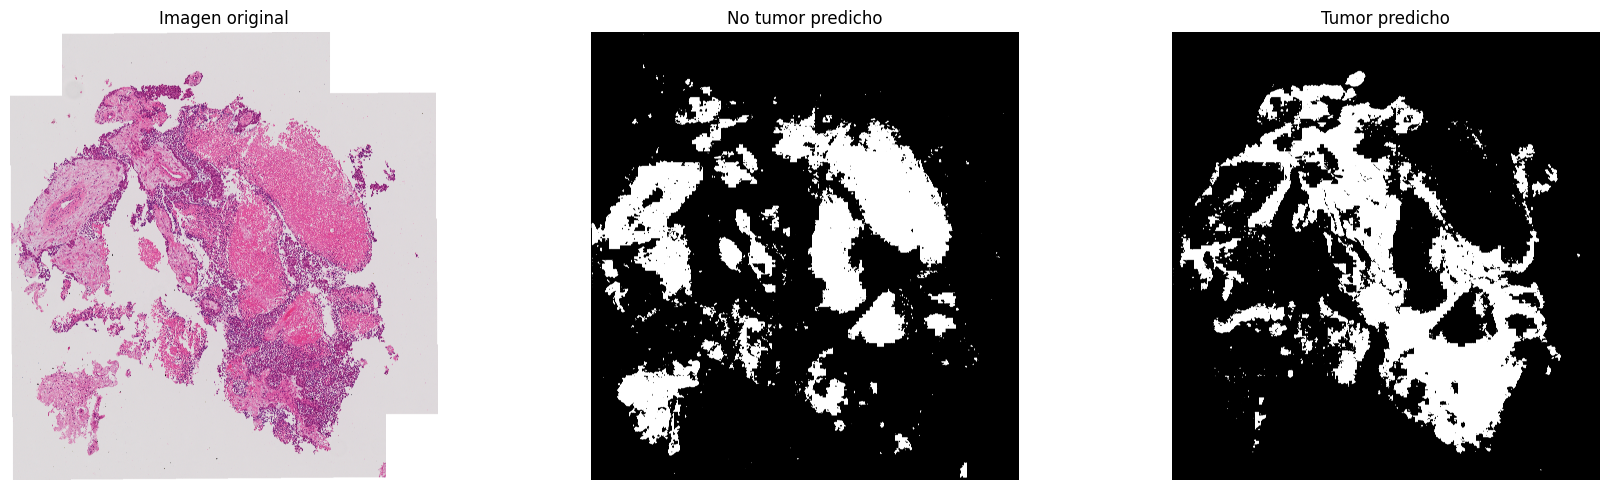

Clase 1 (No tumor): 275 objetos
Clase 2 (Tumor): 280 objetos
GeoJSON guardado en: C:\Users\franc\Downloads\resultados_deeplab_final\geojson_qupath\B2291CR1_1.ome_full_prediction_qupath.geojson
Número de objetos exportados: 555
========== VALIDACIÓN GEOJSON ==========
Archivo original: C:\Users\franc\Downloads\resultados_deeplab_final\geojson_qupath\B2291CR1_1.ome_full_prediction_qupath.geojson
Features originales: 555
Features válidas originalmente: 553
Features inválidas detectadas: 2
Geometrías reparadas: 2
Features finales reparadas: 545
Features descartadas: 13
GeoJSON reparado: C:\Users\franc\Downloads\resultados_deeplab_final\geojson_qupath\B2291CR1_1.ome_full_prediction_qupath_REPAIRED.geojson
Tamaño reparado MB: 1.9912405014038086

Primeras geometrías inválidas:
Feature 327: Ring Self-intersection[5504 11135]
Feature 341: Self-intersection[4838.76470588235 10420.0882352941]

GeoJSON solo con geometrías válidas: C:\Users\franc\Downloads\resultados_deeplab_final\geojson_qupath\B2

In [23]:

# =============================================================================
# EJECUCIÓN PRINCIPAL
# =============================================================================
# Este bloque hace una de las dos cosas, según RUN_MODE:
#   - RUN_MODE = "train": procesa casos, entrena/reentrena DeepLab y guarda checkpoint.
#   - RUN_MODE = "export": procesa casos, carga checkpoint, evalúa un caso y exporta GeoJSON.
#
# Para añadir nuevas imágenes al entrenamiento:
#   1) añade imagen + geojson a TFM/imagenes y TFM/geojsons
#   2) deja SPLIT_MODE = "fixed_plus_new_train"
#   3) pon RUN_MODE = "train"
#   4) ejecuta el notebook.
#
# Para solo evaluar/exportar:
#   1) pon RUN_MODE = "export"
#   2) rellena BEST_MODEL_PATH con tu checkpoint real
#   3) rellena CASE_ID_TO_EXPORT si quieres un caso concreto
#   4) ejecuta el notebook.


if RUN_MODE == "train":
    all_case_data, all_patches_meta, all_patches = process_all_cases(
    images_dir=IMAGES_DIR,
    geojson_dir=GEOJSON_DIR,
    validate_cases=VALIDATE_CASES)

    final_result = train_deeplab_final(
        all_case_data=all_case_data,
        split_mode=SPLIT_MODE,
        train_from_checkpoint=TRAIN_FROM_CHECKPOINT,
        checkpoint_to_continue=CHECKPOINT_TO_CONTINUE,
        output_checkpoint=TRAIN_OUTPUT_CHECKPOINT,
        num_epochs=NUM_EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        loss_name=LOSS_NAME,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
        device=DEVICE)

elif RUN_MODE == "export":
    all_case_data, all_patches_meta, all_patches = process_all_cases(
    images_dir=IMAGES_DIR,
    geojson_dir=GEOJSON_DIR,
    validate_cases=VALIDATE_CASES)

    export_result = run_export_case(
        all_case_data=all_case_data,
        checkpoint_path=BEST_MODEL_PATH,
        case_id=CASE_ID_TO_EXPORT,
        export_classes=EXPORT_CLASSES,
    )
elif RUN_MODE == "predict_full":

    print("Modo: predicción sobre imagen completa sin anotación")
    print("Imagen:", FULL_IMAGE_PATH)

    # 1. Cargar modelo DeepLabV3 desde checkpoint
    model, checkpoint = load_deeplab_for_inference(
        checkpoint_path=BEST_MODEL_PATH,
        device=DEVICE
    )¡

    # 2. Leer imagen completa
    image = read_full_rgb_image(FULL_IMAGE_PATH)

    print("Imagen cargada:", image.shape)

    # 3. Predicción sobre toda la imagen con sliding window
    pred_mask_full, prob_map_full = predict_large_image_sliding_window_for_export(
        model=model,
        image=image,
        device=DEVICE,
        patch_size=FULL_PATCH_SIZE,
        stride=FULL_STRIDE,
        target_size=None,
        num_classes=NUM_CLASSES,
        batch_size=FULL_BATCH_SIZE,
    )

    print("Predicción completa:", pred_mask_full.shape)
    print("Clases predichas:", np.unique(pred_mask_full, return_counts=True))

    # 4. Visualización rápida de clases
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Imagen original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(pred_mask_full == 1, cmap="gray")
    plt.title("No tumor predicho")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask_full == 2, cmap="gray")
    plt.title("Tumor predicho")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # 5. Exportar GeoJSON a QuPath
    output_geojson_path = GEOJSON_OUTPUT_DIR / f"{FULL_CASE_ID}_full_prediction_qupath.geojson"

    export_full_prediction_to_qupath_geojson_using_existing(
    pred_mask=pred_mask_full,
    output_path=output_geojson_path,
    export_classes=FULL_EXPORT_CLASSES,
    min_area=FULL_EXPORT_MIN_AREA,
    simplify_epsilon=FULL_EXPORT_SIMPLIFY_EPSILON,
    morph_kernel_size=FULL_EXPORT_MORPH_KERNEL_SIZE,
)
    # 6. Validar y reparar GeoJSON
    repaired_geojson_path, valid_only_geojson_path, invalid_report = validate_and_repair_qupath_geojson(
    input_path=output_geojson_path,
    min_area=FULL_EXPORT_MIN_AREA,
    simplify_tolerance=2.0,
    preserve_topology=True,
    save_valid_only=True)

    print("Proceso terminado.")
    print("GeoJSON original:", output_geojson_path)
    print("GeoJSON reparado para QuPath:", repaired_geojson_path)

else:
    raise ValueError("RUN_MODE debe ser 'train', 'export' o 'predict_full' ")
